<div style="text-align: center;">
<hr>
<h1><b>COUVERTURE D'OPTIONS DANS LE MODÈLE DE BLACK-SCHOLES</b></h1>
<h3>Stratégie <i>delta</i>, erreur de réplication et calibration sur données de marché</h3>
<h4>Vincent Neves &middot; Arthur Filippi</h4>
<p>École Polytechnique, CMAP (Centre de Mathématiques Appliquées)<br>
<a href="mailto:vincent.neves@polytechnique.edu">vincent.neves@polytechnique.edu</a> &middot; <a href="mailto:arthur.filippi@polytechnique.edu">arthur.filippi@polytechnique.edu</a></p>
<hr>
</div>

## Abstract

This work studies the **hedging of an option contract** in the discretised Black-Scholes model. An option is a risk-transfer contract: its issuer must be able to honour the *payoff* at maturity, and builds for this a replicating portfolio split between the risky asset $S_{t_i}$ (log-normal dynamics) and a risk-free asset with rate $r$.

We proceed in three stages. **(1) Theory** : we establish the model's properties (expectation of $S_{t_i}$, integrability conditions, change to the risk-neutral measure $\mathbb{Q}$), prove the **Black-Scholes formula** for call/put prices and the put-call parity, and show that the option price solves a parabolic **PDE**. **(2) Discrete hedging** : the **delta** strategy is implemented and the replication error $\Delta_T^h = V_T^h - \Phi(S_T)$ is analysed; we observe empirically $\mathbb{E}[|\Delta_T^h|]\propto N^{-1/3}$. The delta is also estimated without a closed form by **Monte-Carlo** (centred finite differences). For a discontinuous **digital** payoff, the standard delta strategy fails, and an **adaptive resampling** scheme near maturity restores convergence. **(3) Market data** : a strongly consistent volatility estimator is derived and applied to the **DAX** index, confirming the relevance of the Black-Scholes model for liquid underlyings.

Throughout, the consistency of the discrete schemes with continuous theory, and their limits, is illustrated.

## 1 - LE MODÈLE

Nous calculons $\mathbb{E}(S_{t_i})$.



<u>Cas i = 0 </u> : Pour $\ i = 0$, $S_{t_i} = x$, i.e. $\mathbb{E}(S_{t_0}) = x$. 

<u>Cas i > 0 </u>: Soit $i \in [1,N].$
Posons : 
$$
k : u \in \mathbb{R} \longmapsto \exp\left(-\frac{(u-\sigma \sqrt{h}i)^2} {2i}+\frac{\sigma^2 h i}{2}\right) 
$$

Nous avons $k \in L^1(\mathbb{R}, \mathbb{R})$, et pour $u \in \mathbb{R}$, on a de plus : 

$$
k(u) = \exp\left(\sigma\sqrt{h}u-\frac{u^2}{2i}\right) = \exp\left(\sigma\sqrt{h}u\right) \exp\left(-\frac{u^2}{2i}\right)
$$

D'où la formule de transfert s'applique pour $ H : X \in \mathbb{R} \longmapsto \exp\left(\sigma \sqrt{h} X \right) $, et, comme $\sum_{j=1}^{i}N_j \sim \mathcal{N}(0, i) $, on a :

\begin{align*}
\mathbb{E}(S_{t_i}) &= x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i\right)\mathbb{E}\left(\exp\left(\sigma \sqrt{h}\sum_{j=1}^{i}N_j\right)\right) \\
&= x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i\right)\int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi i}}\exp\left(\sigma\sqrt{h}u-\frac{u^2}{2i}\right)du \\
&= \frac{x}{\sqrt{2\pi i}}\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i\right)\int_{-\infty}^{+\infty}\exp\left(-\frac{(u-\sigma \sqrt{h}i)^2} {2i}+\frac{\sigma^2 h i}{2}\right)du \\
\end{align*}

Par changement de variable : $$ v = \frac{u - \sigma \sqrt{h}i}{\sqrt{2 i}}$$ on obtient : 
\begin{align*}
\mathbb{E}(S_{t_i}) &= \frac{x \sqrt{2 i} }{\sqrt{2\pi i}}\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i+\frac{\sigma^2t_i}{2}\right)\int_{-\infty}^{+\infty}\exp(-v^2)dv \\
&= x\exp(bt_i)
\end{align*}

D'où $\boxed{\mathbb{E}(S_{t_i}) = x\exp(bt_i)} $.

Vérifions que pour toute fonction f pour laquelle il existe $ 0 \leq c < \frac{1}{\sigma^2 T} , C \geq 1$ telles que pour
$y \in \mathbb{R}_+^*$, $|f(y)| \leq C(1 + \exp\left(c \left| \ln y\right| ^ 2 \right))$ alors $\mathbb{E}(f(S_{t_i})) < + \infty $ pour tout $i \in [1, N] $.





Soit $f$ une fonction vérifiant cette hypothèse, et $ c \in [0, \frac{1}{\sigma^2 T}[ , C \geq 1$ associés. 

Posons : 
$$
g : u \in \mathbb{R} \longmapsto \exp\left(c \left (\ln(x) + \left(b-\frac{\sigma^2}{2}\right) t_i + \sigma \sqrt{h} u \right)^2\right) 
$$

Alors $g \in C^{0}(\mathbb{R}, \mathbb{R})$. Soit $u \in \mathbb{R}$. On a : 

$$ g(u) \exp\left( - \frac{u^2}{2 i}\right) = \exp\left(- u^2 \left(\frac{1}{2 i} - c \sigma ^2 h \right) + 2c\sigma\sqrt{h}u\left(\ln(x) + \left(b-\frac{\sigma^2}{2}\right) t_i\right) + \left(\ln(x) + \left(b-\frac{\sigma^2}{2}\right) t_i\right)^2\right)$$

D'où $u \in \mathbb{R} \longmapsto g(u) \exp\left( - \frac{u^2}{2 i}\right) \in L^1(\mathbb{R}, \mathbb{R})$ si et seulement si le terme en $u^2$ est strictement négatif, *i.e.* si et seulement si : $\frac{1}{2 i} - c \sigma ^2 h > 0 $.

Or, on a $\frac{1}{2 i} - c \sigma ^2 h > \frac{1}{2 i} - \frac{h}{T} = \frac{1}{2 i} - \frac{1}{N} $, *i.e.* l'inégalité souhaitée n'est pas toujours vérifiée. Il aurait fallu que $ c < \frac{1}{2 \sigma^2 T} $ pour obtenir ce résultat.

Supposons désormais que $ c < \frac{1}{2 \sigma^2 T} $. Nous avons alors que $u \in \mathbb{R} \longmapsto g(u) \exp\left( - \frac{u^2}{2 i}\right) \in L^1(\mathbb{R}, \mathbb{R})$.

D'où, par formule de transfert, $\mathbb{E}(g(S_{t_i})) < + \infty $, *i.e.* $ \mathbb{E}(\exp\left( c |\ln(S_{t_i})|^2\right) < + \infty$

D'où, par conservation de la croissance par passage à l'espérance, $\mathbb{E}(|f(S_{t_i})|) \leq \mathbb{E}\left(C\left(1 + \exp\left( c |\ln(S_{t_i})|^2\right)\right)\right) < + \infty$, ie pour tout $i \in [1, N]$, $\boxed{\mathbb{E}(S_{t_i}) < + \infty} $.



 On appelle probabilité risque neutre $ \mathbb{Q} $ celle sous laquelle la tendance de l’actif correspond au taux
d’intérêt $r$ de l’actif sans risque, *i.e.* sous $ \mathbb{Q} $ l’actif risqué obéit à l’évolution suivante, pour tout $t_i \in \Lambda$,
$$ S_{t_i} = x \exp\left(\left(r - \frac{\sigma^2}{2} \right)t_i + \sigma \sqrt{h} \sum_{j=1}^{i}N_j \right) $$ où les $ (\overline{N}_j )_{j \in \mathbb{N}^*} $ sont des variables aléatoires normales centrées réduites i.i.d. définies sur l’espace de
probabilité $(\Omega, \mathcal{F}, \mathbb{Q})$. Établissons que pour $f$ vérifiant les conditions de croissance établies précédemment
$$ \mathbb{E}^{\mathbb{Q}}[f(S_{t_i})] = \mathbb{E}^{\mathbb{P}}[f(S_{t_i}) \mathcal{E}_T] \ \ avec \ \mathcal{E}_T = \exp\left( \mu \sqrt{h} \sum_{j=1}^N N_j - \frac{\mu^2}{2} T \right) \ \ et \ \ \mu = \frac{r - b}{\sigma}$$ 


Soit $f$ une fonction vérifiant les conditions de croissance établies précédemment.

Considérons le vecteur aléatoire $ V = \left(\sum_{j=1}^{i}N_j , \sum_{j=i+1}^{N}N_j \right) $, et posons $ X = \sum_{j=1}^{i}N_j $ et $Y = \sum_{j=i+1}^{N}N_j$ . Comme les $(N_j )_{j \in \mathbb{N}^*}$ sont des variables aléatoires normales centrées réduites i.i.d, $X$ et $Y$ son indépendantes.

Soit $i \in [1,N].$ Montrons tout d'abord que $ \mathbb{E}^{\mathbb{P}}[f(S_{t_i}) \mathcal{E}_T] < + \infty $. Remarquons que, par indépendance, montrer ceci revient à démontrer que les deux espérances en $(3.1)$ sont finies : 

\begin{align*}
\mathbb{E}^{\mathbb{P}}[f(S_{t_i}) \mathcal{E}_T] 
&= \mathbb{E}^{\mathbb{P}}\left[f\left( x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} X\right) \right)\exp\left(- \frac{\mu^2 T}{2} + \mu \sqrt{h} (X+Y) \right) \right] \\
&= \exp\left(- \frac{\mu^2 T}{2}\right) \mathbb{E}^{\mathbb{P}} \left[\exp(\mu \sqrt{h} Y)\right] \mathbb{E}^{\mathbb{P}}\left[ f\left( x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} X\right)\right) \exp\left(\mu \sqrt{h} X \right)\right] \tag{3.1}
\end{align*}

On a d'une part, en reprenant les mêmes calculs que précédemment, que $$\mathbb{E}^{\mathbb{P}} \left[\exp(\mu \sqrt{h} Y)\right]= \exp\left(\frac{\mu^2 h (N - i)}{2}\right) \tag{3.2}$$

D'autre part, reprenons le raisonnement appliqué en On a que

$$\exp\left(\mu \sqrt{h} X \right)|f(S_{t_i})| \leq C \exp\left(\mu \sqrt{h} X \right)+ C\exp\left(\mu \sqrt{h} X \right)\exp\left(c ln(S_{t_i}) ^ 2 \right)$$

Or, le premier terme est d'espérance fini, et l'ajout du terme $\exp\left(\mu \sqrt{h} X \right)$ ajoute un terme en u sous l'intégrale du deuxième terme dans le raisonnement mené précédemment, ce qui ne change pas la convergence de l'intégrale. Ainsi, on en déduit que $\mathbb{E}^{\mathbb{P}}\left[ f\left( x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} X\right)\right) \exp\left(\mu \sqrt{h} X \right)\right] < + \infty $, *i.e.* que $ \mathbb{E}^{\mathbb{P}}[f(S_{t_i}) \mathcal{E}_T] < + \infty $.

On a par formule de transfert: 

$$\mathbb{E}^{\mathbb{P}}\left[ f\left( x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} X\right)\right) \exp\left(\mu \sqrt{h} X \right)\right] = \int_{-\infty}^{+\infty}\frac{1}{\sqrt{2\pi i}} f\left( x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} u\right)\right) \exp\left(\mu \sqrt{h} u \right) \exp\left(-\frac{u^2}{2 i}\right) du $$

Par changement de variable : $ v = u - \frac{\mu t_i}{\sqrt{h}}$ on obtient :

\begin{align*}
\mathbb{E}^{\mathbb{P}}\left[ f\left( x\exp\left(\left(b-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} X\right)\right) \exp\left(\mu \sqrt{h} X \right)\right] &= \frac{1}{\sqrt{2\pi i}}\int_{-\infty}^{+\infty} f\left( x\exp\left(\left(r-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} v\right)\right) \exp\left(\mu \sqrt{h} \left(v + \frac{\mu t_i}{\sqrt{h}} \right) \right) \exp\left(-\frac{\left(v + \frac{\mu t_i}{\sqrt{h}} \right)^2}{2 i}\right) dv \\ &= \frac{\exp\left(\mu^2 t_i - \frac{\mu^2 t_i^2}{2 h i}\right)}{\sqrt{2\pi i}}\int_{-\infty}^{+\infty} f\left( x\exp\left(\left(r-\frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} v\right)\right)\exp\left(- \frac{v^2}{2i} \right) dv \\ &= \exp\left(\frac{\mu^2 h i}{2}\right) \mathbb{E}^{\mathbb{Q}}[f(S_{t_i})] \tag{3.3}
\end{align*}

D'où, en combiant les résulats $(3.1)$, $(3.2)$ et $(3.3)$, on en déduit : $$\mathbb{E}^{\mathbb{P}}[f(S_{t_i}) \mathcal{E}_T] = \mathbb{E}^{\mathbb{Q}}[f(S_{t_i})]\exp\left(\frac{\mu^2 h i}{2}\right) \exp\left(\frac{\mu^2 h (N - i)}{2}\right) \exp\left(- \frac{\mu^2 T}{2}\right) = \mathbb{E}^{\mathbb{Q}}[f(S_{t_i})], ie : $$ 

$$\boxed{\mathbb{E}^{\mathbb{P}}[f(S_{t_i}) \mathcal{E}_T] = \mathbb{E}^{\mathbb{Q}}[f(S_{t_i})]}$$

Donnons l’expression exacte de $C_{K,T}(t, y)$, $P_{K,T}(t, y)$ ci-dessus en fonction de la fonction de répartition
de la loi normale $y \in \mathbb{R} \longmapsto F_\mathcal{N}(y) = \mathbb{P}(N_1 \leq y)$ (formule de Black et Scholes).

Soit $t_i \in \Lambda $ et $y \in \mathbb{R}_+^*$.

Reprenons le vecteur aléatoire $V$ introduit précédemment, et remarquons que : 
$$\mathbb{E}^\mathbb{Q} \left[ f_{C_K}(S_T) \,\middle|\, S_{t_i} = y \right] = \mathbb{E}^\mathbb{Q} \left[\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t_i) + \sigma \sqrt{h} Y\right) - K \right)^+ \,\middle|\, S_{t_i} = y \right]$$

Or, $S_{t_i}$ et $Y$ sont indépendants car $X$ et $Y$ le sont. On en déduit que : 

\begin{align*}
\mathbb{E}^\mathbb{Q} \left[ f_{C_K}(S_T) \,\middle|\, S_{t_i} = y \right] &= \mathbb{E}^\mathbb{Q} \left[\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t_i) + \sigma \sqrt{h} Y\right) - K \right)^+ \right] \\ &= \mathbb{E}^\mathbb{Q} \left[\max\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t_i) + \sigma \sqrt{h} Y\right) - K, 0 \right) \right]
\end{align*}

Montrons tout d'abord que $\mathbb{E}^\mathbb{Q} \left[ f_{C_K}(S_T) \,\middle|\, S_{t_i} = y \right] < + \infty $. Posons : $$ M_1 = \frac{1}{\sigma \sqrt{T-t_i}}\left( \ln(\frac{K}{y}) - \left(r+\frac{\sigma^2}{2}\right)(T- t_i) \right)$$ et $$ M_2 = \frac{1}{\sigma \sqrt{T-t_i}}\left( \ln(\frac{K}{y}) - \left(r-\frac{\sigma^2}{2}\right)(T- t_i) \right)$$. 

Soit $ A > M_2$.

$$\int_{-A}^{+A} \max\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t_i) + \sigma \sqrt{h} u\right) - K, 0 \right) \frac{1}{\sqrt{2 \pi (N-i)}} \exp\left(-\frac{u^2}{2(N-i)} \right)du = \frac{y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t_i)\right)}{\sqrt{2 \pi (N-i)}} \int_{M_2 \sqrt{N-i}}^{+A}\exp\left(\sigma \sqrt{h} u -\frac{u^2}{2(N-i)} \right)du - \frac{K}{\sqrt{2 \pi (N-i)}}\int_{M_2 \sqrt{N-i}}^{+A}\exp\left(-\frac{u^2}{2(N-i)} \right)du \tag{4.1}$$

On en déduit par convergence de ces intégrales pour $A \to +\infty$ que $\mathbb{E}^\mathbb{Q} \left[ f_{C_K}(S_T) \,\middle|\, S_{t_i} = y \right] < + \infty $. D'où, en reprenant $(4.1)$, on a :

$$C_{K,T}(t_i, y) = \exp\left(-r(T - t_i) \right)\frac{y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t_i)\right)}{\sqrt{2 \pi (N-i)}} \int_{M_2 \sqrt{N-i}}^{+ \infty}\exp\left(\sigma \sqrt{h} u -\frac{u^2}{2(N-i)} \right)du - \frac{K \exp\left(-r(T - t_i) \right)}{\sqrt{2 \pi (N-i)}}\int_{M_2 \sqrt{N-i}}^{+ \infty}\exp\left(-\frac{u^2}{2(N-i)} \right)du$$

Par changement de variable, on en déduit que : 

\begin{align*}
C_{K,T}(t_i, y) &= \frac{y}{\sqrt{2\pi}} \int_{M_1}^{+ \infty} \exp\left(-\frac{v^2}{2}\right)dv - K \frac{\exp\left(-r(T - t_i)\right)}{\sqrt{2 \pi}} \int_{M_2}^{+ \infty} \exp\left(-\frac{v^2}{2}\right)dv \\ &= y\left(1 - F_\mathcal{N}(M_1) \right) - K \exp\left(-r(T - t_i)\right)\left(1 - F_\mathcal{N}(M_2) \right) \\ &= yF_\mathcal{N}(-M_1) - K \exp\left(-r(T - t_i)\right)F_\mathcal{N}(-M_2) 
\end{align*}

D'où, et en appliquant une méthode analogue pour $P_{K,T}(t, y)$, on a pour tout $t \in \Lambda $ et $y \in \mathbb{R}_+^*$: 

$$ \boxed{C_{K,T}(t, y) = yF_\mathcal{N}(-M_1) - K \exp\left(-r(T - t)\right)F_\mathcal{N}(-M_2) }$$

$$ \boxed{P_{K,T}(t, y) = -yF_\mathcal{N}(M_1) + K \exp\left(-r(T - t)\right)F_\mathcal{N}(M_2) }$$



Montrons la relation de parité call-put : $C_{K,T}(t, y) - P_{K,T}(t, y) = y - K\exp\left(-r(T - t)\right)$. 

Soit $t \in \Lambda $ et $y \in \mathbb{R}_+^*$. Par ce qui précède, comme $F_\mathcal{N}(-x) = 1 - F_\mathcal{N}(x)$
\begin{align*}
C_{K,T}(t, y) - P_{K,T}(t, y) &= y \left( F_\mathcal{N}(-M_1) + F_\mathcal{N}(M_1) \right) - K \exp\left(-r(T - t)\right)\left(F_\mathcal{N}(-M_2) + F_\mathcal{N}(M_2) \right)\ \\ &= y - K \exp\left(-r(T - t)\right)
\end{align*}

*i.e.* $\boxed {C_{K,T}(t, y) - P_{K,T}(t, y) = y - K\exp\left(-r(T - t)\right)}$.

Estimons pour $x = 100$, $T = 1$, $b = .02$, $\sigma = .2$ les quantités $C_K(T,x)$ pour $K \in \{90, 100, 110, 120\}$.
On utilisera deux estimateurs, celui naturellement associé à $C_K(T,x)$ puis celui qui exploite la relation
de parité $(\mathcal{P})$. Dans les deux cas on tracera les intervalles de confiance associés.

Bien que $C_K(T,x)$ ne soit pas explicitement défini dans l'étude, le contexte du problème suggère que cette quantité correspond à $C_{K,T}(0,x)$, ce que nous utiliserons par la suite. 

Remarquons qu'on a : 

\begin{align*}
C_{K,T}(0,y) = \exp(-rT)\mathbb{E}^\mathbb{Q} \left[ f_{C_K}(S_T) \,\middle|\, S_{t_0} = y \right] &= \exp(-rT)\mathbb{E}^\mathbb{Q} \left[\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} \overline{N}_1\right) - K \right)^+ \right] \\ &= \exp(-rT)\mathbb{E}^\mathbb{Q} \left[\max\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} \overline{N}_1\right) - K, 0 \right) \right]
\end{align*}

Posons $\phi : u \in \mathbb{R} \longmapsto \max\left(x\exp\left(\left(r-\frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} u\right) - K, 0 \right) $ et $ g : u \in \mathbb{R} \longmapsto \exp(rT)u$ . 

On a : $ g(C_K(T,x)) = \mathbb{E}^\mathbb{Q} \left[ \phi(\overline{N}_1) \right] $. Soit $ n \in \mathbb{N}$. Par méthode des moments, on associe à $ C_K(T,x) $ l'estimateur : 

$$ \widehat{C_K}(T,x)_n^1 = \frac{\exp(-rT)}{n}\sum_{j=1}^{n}\phi(\overline{N}_j)$$

qui converge fortement par continuité de $g$ et loi forte des grands nombres vers $ C_K(T,x) $. 

De la même manière, en posant $\psi : u \in \mathbb{R} \longmapsto \max\left(K - x\exp\left(\left(r-\frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} u\right), 0 \right) $, on associe à $ P_K(T,x) $ l'estimateur $\widehat{P_K}(T,x)_n = \frac{\exp(-rT)}{n}\sum_{j=1}^{n}\psi(\overline{N}_j)$, *i.e.*, en posant $\widehat{C_K}(T,x)_n^2 = x - K \exp(-rT) + \frac{\exp(-rT)}{n}\sum_{j=1}^{n}\psi(\overline{N}_j)$, on a construit un deuxième estimateur de $ C_K(T,x) $ à partir de la relation de parité $(P)$.

De plus, pour un estimateur $\widehat{C_K}_n$ l'intervalle de confiance $I_{0,05}$ de niveau 95% est donné par $I_\alpha = \left[ \widehat{C_K}_n - 1,96\frac{\widehat{\sigma}_n}{\sqrt{n}} , \widehat{C_K}_n + 1,96\frac{\widehat{\sigma}_n}{\sqrt{n}}\right] $ où $\widehat{\sigma}_n$ est l'écart-type empirique associé.

On simule donc ainsi, en jouant sur le paramètre N_sim correspondant au nombre de simulation utlisée, $C_K(T,x)$ et l'intervalle de confiance associée pour atteindre un niveau de confiance de 95 % (par soucis de lisibilité des intervalles de confiance sur le graphique, on ajoute un léger offset pour décaler les résultats sur la droite pour la deuxième méthode) : 


K = 90, estimateur C_K_1 ≈ 15.1629 
marge =  1.0217865579439076
K = 100, estimateur C_K_1 ≈ 9.0295 
marge =  0.845844334276955
K = 110, estimateur C_K_1 ≈ 4.9789 
marge =  0.6466144551229952
K = 120, estimateur C_K_1 ≈ 2.5657 
marge =  0.4611791130593284
K = 90, estimateur C_K_2 ≈ 14.6728
marge =  0.3566043904329599
K = 100, estimateur C_K_2 ≈ 8.9287
marge =  0.575755073137632
K = 110, estimateur C_K_2 ≈ 5.0179
marge =  0.7860798050910291
K = 120, estimateur C_K_2 ≈ 2.6161
marge =  0.9563734482064947


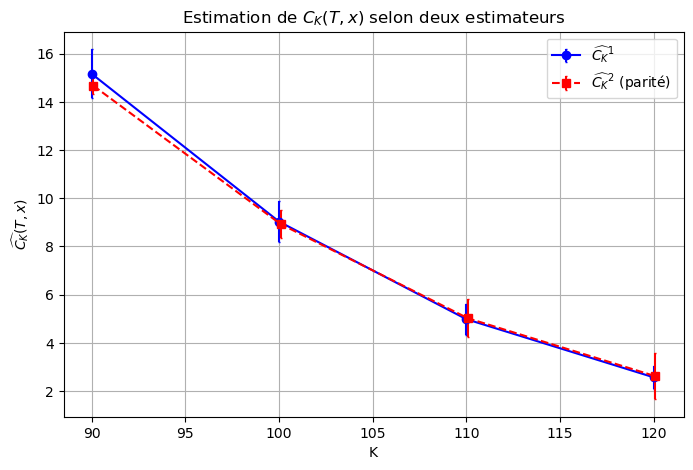

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

np.random.seed(4)

####################### ESTIMATION DU PRIX DES CALLS SELON DIFFÉRENTS STRIKES ######################
####################### UTILISATION DE DEUX ESTIMATEURS DIFFÉRENTS #################################    
    

### paramètrage du modèle : 
x = 100
T = 1
b = 0.02 
sigma = 0.2
liste_K = [90, 100, 110, 120]
N_sim = 10**3 # taille de l'échantillon, à moduler pour affiner la précision du modèle et réduite l'intervalle de confiance

N_ensemble1 = np.random.normal(0, 1, N_sim) #simulation 1 pour l'estimateur 1 
N_ensemble2 = np.random.normal(0, 1, N_sim) #simulation 2 pour l'estimateur 2

### On implémente phi et psi : 

def phi(N_j, K):
    # renvoie le payoff d'un call
    return np.maximum(x * np.exp((b - 0.5 * sigma**2)*T + sigma * np.sqrt(T) * N_j) - K, 0)

def psi(N_j, K):
    # renvoie le payoff d'un put
    return np.maximum(K - x * np.exp((b - 0.5 * sigma**2)*T + sigma * np.sqrt(T) * N_j), 0)


def intervalle_confiance(echantillon):
    ecart_type = np.std(echantillon, ddof=1) # Calcul de l'écart-type corrigé de l'échantillon, avec un degré de liberté
    marge = 1.96 * ecart_type / np.sqrt(len(echantillon)) # Calcul de la marge d'intervalle de confiance pour un intervalle de 95% (1.96 ≈ quantile de la loi normale standard)
    return marge

estimateurs1 = []
ic1 = []
for K in liste_K:
    valeurs_phi = []
    for i in range(N_sim):
        # Simulation du payoff actualisé pour chaque échantillon
        valeurs_phi.append(np.exp(-b*T)*phi(N_ensemble1[i], K))
    C = np.mean(valeurs_phi)  # Moyenne : estimateur du prix de l'option
    estimateurs1.append(C)
    marge = intervalle_confiance(valeurs_phi) # Calcul de l'intervalle de confiance
    ic1.append(marge)
    print(f"K = {K}, estimateur C_K_1 ≈ {C:.4f} ")
    print("marge = ", marge)
    
    
estimateurs2 = []
ic2 = []
for K in liste_K:
    valeurs_psi = []
    for i in range(N_sim):
        # Simulation du payoff actualisé pour chaque échantillon
        valeurs_psi.append(x - K * np.exp(-b*T) + np.exp(-b*T)*psi(N_ensemble2[i], K))
    C =  np.mean(valeurs_psi)  # Moyenne : estimateur du prix via parité put-call
    marge = intervalle_confiance(valeurs_psi) # Calcul de l'intervalle de confiance
    estimateurs2.append(C) 
    ic2.append(marge)
    print(f"K = {K}, estimateur C_K_2 ≈ {C:.4f}")
    print("marge = ", marge)

offset = 0.08  # Décalage horizontal pour décaler les points rouges des bleus, ce qui rend lisible les intervalles de confiance
liste_K2 = [K +  offset for K in liste_K]
plt.figure(figsize=(8,5))

# Courbe estimateur 1 (call direct) ; on passe par errorbar pour ajouter l'intervalle de confiance associé à chaque point
plt.errorbar(liste_K, estimateurs1, yerr=ic1, fmt='o-', color='blue', label=r"$\widehat{C_K}^1$", capsize=1)

# Courbe estimateur 2 (via parité put-call) ; on passe par errorbar pour ajouter l'intervalle de confiance associé à chaque point
plt.errorbar(liste_K2, estimateurs2, yerr=ic2, fmt='s--', color='red', label=r"$\widehat{C_K}^2$ (parité)", capsize=1)


plt.title(r"Estimation de $C_K(T, x)$ selon deux estimateurs")
plt.xlabel("K")
plt.ylabel(r"$\widehat{C_K}(T, x)$")
plt.grid(True)
plt.legend()
plt.show()

## 2 - PORTEFEUILLE AUTOFINANÇANT ET COUVERTURE DISCRÈTE

Montrons que $(t,y)\in [0,T]\times\mathbb{R}_+^* \;\longmapsto\; C_{K,T}(t,y)$ est solution de l’équation aux dérivées partielles:

$\text(EDP) \begin{cases}
\partial_t v(t, y) + r y \, \partial_y v(t, y) + \frac{1}{2} \sigma^2 y^2 \, \partial_{yy}^2 v(t, y) - r v(t, y) = 0, & \text{pour } (t, y) \in [0, T] \times \mathbb{R}_+^* \\
v(T, y) = \Phi(y), & \text{pour } y \in \mathbb{R}_+^*
\end{cases}$

Soit $y \in \mathbb{R}_+^*$. Pour t = T, $C_{K,T}(t,y) = \mathbb{E}^{\mathbb{Q}}\left[\left( y - K \right)^+\right] = \left( y - K \right)^+ = \Phi(y)$ . D'où $\boxed{C_{K,T}(T,y) = \Phi(y)}$

Pour démontrer que $(t,y)\in [0,T]\times\mathbb{R}_+^* \;\longmapsto\; C_{K,T}(t,y)$ est solution de l’équation aux dérivées partielles, reprenons un raisonnement similaire à celui suivi en Remarquons de plus qu'en vertu des arguments avancés précédemment, on a bien existence de l'espérance employée.

Soit $(t,y)\in [0,T]\times\mathbb{R}_+^*$.

\begin{align*}
C_{K,T}(t,y)
&= e^{-r\,(T-t)}\;
\mathbb{E}^{\mathbb{Q}}\Bigl[\bigl(y\,\exp\bigl((r-\tfrac{\sigma^2}{2})(T-t)
+\sigma\sqrt{T-t}\,\overline N_1\bigr)-K\bigr)^+\Bigr] \\ &= \exp(-r(T-t))\int_{-\infty}^{+\infty} \max\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t) + \sigma \sqrt{T-t} u\right) - K, 0 \right) \frac{1}{\sqrt{2 \pi}} \exp\left(-\frac{u^2}{2} \right)du \\ &= yF_\mathcal{N}(-M_1) - K \exp\left(-r(T - t)\right)F_\mathcal{N}(-M_2)
\end{align*}

car les calculs sont identiques.

On a par théorème fondamental de l'analyse : $$\partial_y C_{K,T}(t,y) = F_\mathcal{N}(-M_1) + \color{green}{\frac{1}{\sigma \sqrt{T-t}} \sqrt{2 \pi} \exp\left(-\frac{M_1^2}{2} \right)} - \color{grey}{K \exp\left(-r(T - t)\right) \frac{1}{y \sigma \sqrt{T-t}\sqrt{2 \pi}} \exp\left(-\frac{M_2^2}{2} \right)} $$

et : 
\begin{align*}
\partial_{yy} C_{K,T}(t,y) &= \frac{1}{ y \sigma \sqrt{T-t} \sqrt{2 \pi}} \exp\left(-\frac{M_1^2}{2} \right) + \frac{2 M_1}{y \sigma^2 (T-t) \sqrt{2 \pi}} \exp\left(-\frac{M_1^2}{2} \right) - K \exp\left(-r(T - t)\right) \frac{2M_2}{y^2 \sigma^2 (T-t)\sqrt{2 \pi}} \exp\left(-\frac{M_2^2}{2} \right) \\ - K \exp\left(-r(T - t)\right)\exp\left(-\frac{M_2^2}{2} \right) \frac{-1}{y^2 \sigma \sqrt{T-t}\sqrt{2 \pi}} \\ &= \frac{\exp\left(-\frac{M_1^2}{2} \right) }{\sqrt{2 \pi}}\left[\color{orange}{\frac{1}{ y \sigma \sqrt{T-t} }} + \color{red}{\frac{ M_1}{y \sigma^2 (T-t)}} \right] + \frac{K}{\sqrt{2 \pi}} \exp\left(-r(T - t)\right)\exp\left(-\frac{M_2^2}{2} \right) \left[\color{blue}{\frac{M_2}{y^2 \sigma^2 (T-t)}} + \color{purple}{\frac{1}{y^2 \sigma \sqrt{T-t}} }\right] 
\end{align*}

et 
\begin{align*}
\partial_t C_{K,T}(t, y) &= -\frac{y}{\sqrt{2 \pi}}\left[ \ln\left(\frac{K}{y}\right)\frac{1}{2 \sigma \left( T - t\right)^\frac{3}{2}} + \frac{r+\frac{\sigma^2}{2}}{2 \sigma \sqrt{T - t}} \right] \exp\left(-\frac{M_1^2}{2} \right) + K r \exp\left(-r(T - t)\right)F_\mathcal{N}(-M_2) \\ - \frac{K}{\sqrt{2 \pi}} \exp\left(-r(T - t)\right) \left[ \ln\left(\frac{K}{y}\right)\frac{1}{2 \sigma \left( T - t\right)^\frac{3}{2}} + \frac{r - \frac{\sigma^2}{2}}{2 \sigma \sqrt{T - t}} \right] \exp\left(-\frac{M_2^2}{2} \right) \\ &= -y \left[\color{red}{ \frac{M_1}{2(T-t)} } + \color{green}{\frac{r}{ \sigma \sqrt{T - t}}} +\color{orange}{\frac{\sigma}{2 \sqrt{T - t}} }\right] \frac{ \exp\left(-\frac{M_1^2}{2} \right) }{\sqrt{2 \pi}} - K r \exp\left(-r(T - t)\right)F_\mathcal{N}(-M_2) - \frac{K}{\sqrt{2 \pi}} \exp\left(-r(T - t)\right) \left[ \color{blue}{\frac{M_2}{2(T-t)}} - \color{grey}{\frac{r}{ \sigma \sqrt{T - t} }} +\color{purple}{ \frac{\sigma}{2 \sqrt{T-t}}}\right] \exp\left(-\frac{M_2^2}{2} \right) 
\end{align*}

Ainsi, dans l'équation différentielle, les termes se substituant (par soucis de lisibilité, on colorie dans les expressions trouvées précédemment les termes s'annulant 2 à 2), on a : 

$$\partial_t C_{K,T}(t, y) + r y \, \partial_y C_{K,T}(t, y) + \frac{1}{2} \sigma^2 y^2 \, \partial_{yy}^2 C_{K,T}(t, y) = r y F_\mathcal{N}(-M_1) - K r \exp\left(-r(T - t)\right)F_\mathcal{N}(-M_2) = r C_{K,T}(t, y)$$

*i.e.* $$\boxed{\partial_t C_{K,T}(t, y) + r y \, \partial_y C_{K,T}(t, y) + \frac{1}{2} \sigma^2 y^2 \, \partial_{yy}^2 C_{K,T}(t, y) - r C_{K,T}(t, y) = 0, \text{pour } (t, y) \in [0, T] \times \mathbb{R}_+^*} $$

Donc $(t,y)\in [0,T]\times\mathbb{R}_+^* \;\longmapsto\; C_{K,T}(t,y)$ est bien solution de cette équation aux dérivées partielles. De plus, on a bien que $P_{K,T}(T,y) = (K - y)^+$, et en exploitant la relation de parité $(P)$ et ce qui précède, on a immédiatement que $(t,y)\in [0,T]\times\mathbb{R}_+^* \;\longmapsto\; P_{K,T}(t,y)$ est solution de cette équation aux dérivées partielles avec $ \Phi(y) = (K - y)^+ $.


Il s'agit désormais de quantifier l'erreur commise par la stratégie de réplication du portefeuille

Montrons que, pour $i \in [0, N-2]$ :
$$v(t_{i+1}, S_{t_{i+1}}) - v(t_i, S_{t_i}) = \partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + \left( v(t_i, S_{t_i}) - S_{t_i} \, \partial_y v(t_i, S_{t_i}) \right) r h + \widetilde{R}^h_i \tag{5.5}$$

Soit $i$ entre $0$ et $N-2$.
Comme $(t, y) \longmapsto v(t, y)$ est solution de (EDP), elle est bien de classe $\mathcal{C}^2$ et donc on peut appliquer la formule de Taylor-Young à l'ordre 2 entre $t_i$ et $t_{i+1}$, en remarquant que $t_{i+1} - t_i = h$ :

On a donc $v(t_{i+1}, S_{t_{i+1}}) = v(t_i, S_{t_i}) + \partial_t v(t_i, S_{t_i})\, h + \partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + \frac{1}{2} \partial_{yy} v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i})^2 + O(h^2)$ (E).

Mais on rappelle que $v(t, y)$ est solution de (EDP) de sorte que $\partial_t v + ry \partial_y v + \frac{1}{2} \sigma^2 y^2 \partial_{yy} v = rv$.

En réinjectant cela dans (E), on a donc :

$$\boxed{v(t_{i+1}, S_{t_{i+1}}) - v(t_{i}, S_{t_{i}}) = \partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + rh(v(t_i, S_{t_i}) - S_{t_i} \partial_y v(t_i, S_{t_i})) + \tilde{R}_i^h}$$
avec $$\boxed{\tilde{R}_i^h := \frac{1}{2} \partial_{yy} (t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i})^2 - \frac{1}{2} \sigma^2 S_{t_i}^2 \partial_{yy} v(t_i, S_{t_i}) h + O(h^2)}$$ où $ O(h^2)$ est le reste de Taylor pour le développement effectué sur $v(t, y)$.

*On fixe donc le taux $\delta_{t_i}$ d'actif risqué recalibré à l'instant $t_i$ à $\partial_y v(t_i, S_{t_i})$.*

- D'une part la contrainte d'autofinancement (A) impose donc $V_{t_{i+1}}^h - V_{t_i}^h = \partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + \delta_{t_i}^0 (S_{t_{i+1}}^0 - S_{t_i}^0)$.

- D'autre part la structure du portefeuille impose : $\delta_{t_i}^0 = \frac{V_{t_i}^h - \delta_{t_i} S_{t_i}}{S_{t_i}^0}$.

- Enfin, l'évolution de l'actif sans risque est telle que $S_t^0 = S_0^0 e^{rt}$, donc $(S_{t_{i+1}}^0 - S_{t_i}^0) = S_0^0 e^{rt_i} (e^{rh} - 1) = S_{t_i}^0 (rh + O(h^2))$ au premier ordre.

De sorte que $\delta_{t_i}^0 (S_{t_{i+1}}^0 - S_{t_i}^0) = \frac{V_{t_i}^h - \partial_y v(t_i, S_{t_i}) S_{t_i}}{S_{t_i}^0} S_{t_i}^0 (rh + O(h^2))$.

On obtient donc finalement : $\delta_{t_i}^0 (S_{t_{i+1}}^0 - S_{t_i}^0) = (V_{t_i}^h - \partial_y v(t_i, S_{t_i}) S_{t_i})(rh + O(h^2))$.

On obtient donc :

$$\left\{
\begin{array}{ll}
(1) : V_{t_{i+1}}^h - V_{t_i}^h = \partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + (V_{t_i}^h - \partial_y v(t_i, S_{t_i}) S_{t_i})rh + O(h^2) \\
(2) : v(t_{i+1}, S_{t_{i+1}}) - v(t_{i}, S_{t_{i}}) = \partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + rh(v(t_i, S_{t_i}) - S_{t_i} \partial_y v(t_i, S_{t_i})) + \tilde{R}_i^h
\end{array}
\right.$$

Et $(1) - (2)$ donne alors : 
$V_{t_{i+1}}^h - V_{t_i}^h - v(t_{i+1}, S_{t_{i+1}}) + v(t_{i}, S_{t_{i}}) = (V_{t_i}^h - v(t_i, S_{t_i}))rh - \tilde{R}_i^h$.

On en déduit finalement la propagation de l'erreur dans le temps :

$$V_{t_{i+1}}^h - v(t_{i+1}, S_{t_{i+1}}) = V_{t_i}^h - v(t_{i}, S_{t_{i}}) + (V_{t_i}^h - v(t_i, S_{t_i}))rh - \tilde{R}_i^h$$

Pour alléger la notation, on notera cette erreur : $\boxed{E_i := V_{t_i}^h - v(t_i, S_{t_i})}$ de sorte que l'on a la relation $$\boxed{E_{i+1} = E_i + rh E_i - \tilde{R}_i^h}$$ avec les conditions initiale et terminale suivantes : $E_0 = 0, E_N = V_T^h - v(T, S_T) = V_T - \phi(S_T)$.

En sommant cette relation télescopique, on obtient : 
$$E_{N-1} = \sum_{i=0}^{N-2} (E_{i+1} - E_i)= \sum_{i=0}^{N-2}(rh E_i - \tilde{R}_i^h) = \sum_{i=0}^{N-2} ((V_{t_i}^h - v(t_i, S_{t_i}))rh - \tilde{R}_i^h)$$

En posant $A := \sum_{i=0}^{N-2} ((V_{t_i}^h - v(t_i, S_{t_i}))rh - \tilde{R}_i^h)$, et en remarquant que $A = E_{N-1}$, on a donc $A - E_{N-1} + E_N = E_N$, de sorte que finalement : 

$$\boxed{V_T^h - v(T, S_T) = V_T - \Phi(S_T) = \sum_{i=0}^{N-2} (( V_{t_i}^h - v(t_i, S_{t_i}) ) r h + R_i^h )
+ ( V_{t_N}^h - V_{t_{N-1}}^h) - ( v(t_N, S_{t_N}) - v(t_{N-1}, S_{t_{N-1}}))}$$

où les restes $R_i^h$ sont de la forme $R_i^h = - \tilde{R}_i^h$ à la différence près que le terme $O(h^2)$ est une différence entre les restes des développements de Taylor de $v(t, y)$ et de $e^{rh} - 1$. 





Nous simulons numériquement l'évolution trajectorielle du portefeuille. L'objectif est de montrer que, pour ce choix de stratégie (i.e. pour le choix du *delta* comme taux d'actif risqué), on a bien une erreur de réplication qui tend vers 0 quand $N \rightarrow + \infty$. Dans un premier temps, on génère l'évolution trajectorielle du portefeuille.

Il faut d'abord déterminer le *delta* du call, on rappelle : $\delta_{t_i} := \partial_y v(t_i, S_{t_i})$.

- On rappelle que, en posant : 
$$ d_1 = \frac{1}{\sigma \sqrt{T-t_i}}\left( \ln(\frac{y}{K}) + \left(r+\frac{\sigma^2}{2}\right)(T- t_i) \right)$$ et $$ d_2 = \frac{1}{\sigma \sqrt{T-t_i}}\left( \ln(\frac{y}{K}) + \left(r-\frac{\sigma^2}{2}\right)(T- t_i) \right)$$

 on a : $$C_{K,T}(t,y) = y F_{\mathcal{N}}(d_1) - K \exp(-r(T-t)) F_{\mathcal{N}}(d_2)$$

- En calculant la dérivée partielle de cette quantité par rapport à $y$, on obtient :
$\frac{\partial C}{\partial y} = F_{\mathcal{N}}(d_1) + y \frac{\partial F_{\mathcal{N}}(d_1)}{\partial y} - \frac{\partial}{\partial y}\left[ K e^{-r(T - t)} F_{\mathcal{N}}(d_2) \right] = F_{\mathcal{N}}(d_1) + \frac{f(d_1)}{\sigma \sqrt{T - t}} - K e^{-r(T - t)} \cdot \frac{f(d_2)}{y \sigma \sqrt{T - t}}$.

 où $f(d_1) = \frac{1}{\sqrt{2 \pi}} e^{-d_1^2/2}$ et $f(d_2) = \frac{1}{\sqrt{2 \pi}} e^{-d_2^2/2}$.

 On remarque que : $\frac{F_{\mathcal{N}}(d_1)}{F_{\mathcal{N}}(d_2)} = e^{-(d_1 + d_2)(d_1 - d_2)/2}$. 

 et : $d_1 - d_2 = \sigma \sqrt{T-t}$ et $d_1 + d_2 = 2d_1 - \sigma \sqrt{T-t}$, donc finalement $\frac{F_{\mathcal{N}}(d_1)}{F_{\mathcal{N}}(d_2)} = e^{-\sigma \sqrt{T-t} d_1 + \sigma^2 (T-t)/2}$.

 En remplaçant $d_1$ par sa valeur (voir ci-dessus), on a finalement $\frac{F_{\mathcal{N}}(d_1)}{F_{\mathcal{N}}(d_2)} = \frac{K}{y}e^{-r(T-t)}$.

L'expression du *delta* du call se simplifie alors et vaut simplement :

$$\boxed{\partial_y v(t_i, S_{t_i}) = F_{\mathcal{N}}(d_1) \text{ avec } d_1 = \frac{1}{\sigma \sqrt{T-t_i}}\left( \ln(\frac{y}{K}) + \left(r+\frac{\sigma^2}{2}\right)(T- t_i) \right)}$$



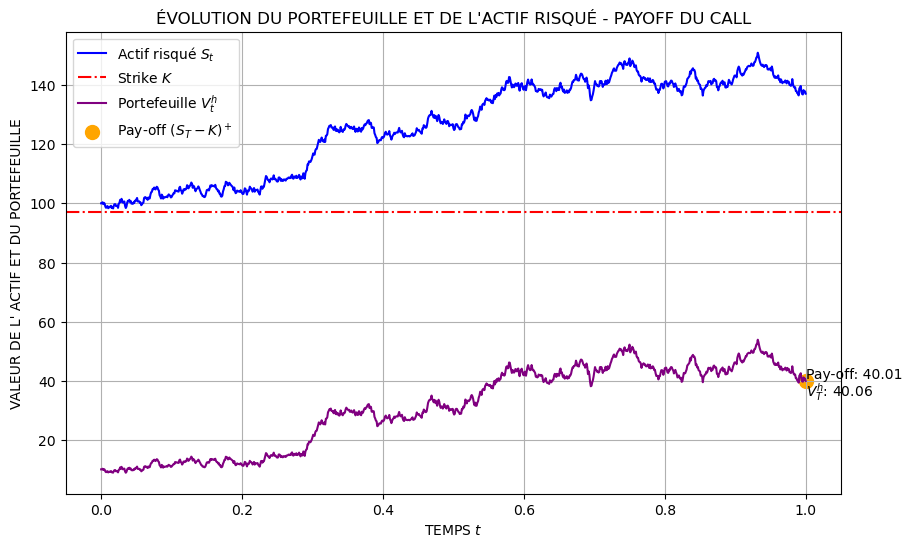

Valeur initiale du portefeuille : 10.210258529971682
Valeur finale du portefeuille : 40.058300024498735
Pay-off de l'option à maturité : 40.01249210777084
Erreur de réplication : 0.045807916727895304


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(4)

## paramètres du modèle de Black-Scholes / paramètres de l'option
S0 = 100 
sigma = 0.2
mu = 0.03
r = 0.015
b = r - sigma*mu
K = 97
T = 1
liste_N = [10, 100, 500, 1000, 5000, 10000]



################# SIMULATION TRAJECTORIELLE DU PORTEFEUILLE ######################################
################# ESTIMATION DE L'ERREUR DE RÉPLICATION ##########################################

## on simule  l'évolution du portefeuille et de l'actif
def simulation_portefeuille(N):
    h = T / N
    t = np.linspace(0, T, N + 1)  # Grille temporelle
    S = np.zeros(N + 1)  # Trajectoire de l'actif risqué
    V = np.zeros(N + 1)  # Valeur du portefeuille
    deltas = np.zeros(N + 1)  # Quantités d'actif risqué

    # Initialisation
    S[0] = S0
    # Valeur initiale du portefeuille : valeur actualisée de l'option
    # Résultats de T4
    M1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    M2 = M1 - sigma * np.sqrt(T)
    V[0] = S0 * norm.cdf(M1) - K * np.exp(-r * T) * norm.cdf(M2)  # Prix initial de l'option
    deltas[0] = norm.cdf(M1)

    # Simuler la trajectoire et mettre à jour le portefeuille
    for i in range(N):
        # Partie aléatoire de l'actif risqué
        N_i = np.random.normal(0, 1)
        
        # Évolution de Black-Scholes
        S[i + 1] = S[i] * np.exp(sigma * np.sqrt(h) * N_i + (b - 0.5 * sigma**2) * h)
        
        # Calcul du delta pour la calibration du portefeuille
        
        # On veut éviter le cas t == T. Comme ce sont des flottants, on ne peut pas tester l'égalité !
        # On met donc une condition un peu arbitraire t < T - 1e-6
        # Cette condition est suffisante pour les valeurs de N que l'on considère dans cette question
        if t[i] < T - 1e-6:
            d1 = (np.log(S[i] / K) + (r + 0.5 * sigma**2) * (T - t[i])) / (sigma * np.sqrt(T - t[i]))
            deltas[i] = norm.cdf(d1)
        else:
            deltas[i] = 0
        
        # Calcul de delta0_i (quantité d'actif sans risque détenue)
        S0_i = np.exp(r * t[i])  # Valeur de l'actif sans risque à t_i
        delta0_i = (V[i] - deltas[i] * S[i]) / S0_i
        
        # Mise à jour la valeur du portefeuille à t_{i+1}
        S0_ip1 = np.exp(r * t[i + 1])
        V[i + 1] = deltas[i] * S[i + 1] + delta0_i * S0_ip1
        
        # Delta pour le dernier pas, avec la même condition arbitraire que plus haut
        if t[i + 1] < T - 1e-6:
            d1 = (np.log(S[i + 1] / K) + (r + 0.5 * sigma**2) * (T - t[i + 1])) / (sigma * np.sqrt(T - t[i + 1]))
            deltas[i + 1] = norm.cdf(d1)
        else:
            deltas[i + 1] = 0

    payoff = np.maximum(S[-1] - K, 0)
    erreur = V[-1] - payoff

    return t, S, V, payoff, erreur


def trace_portefeuille(N):
    t, S, V, payoff, erreur = simulation_portefeuille(N)

    plt.figure(figsize=(10, 6))
    
    # Actif risqué
    plt.plot(t, S, label='Actif risqué $S_t$', color='blue')
    
    # Strike
    plt.axhline(y=K, label='Strike $K$', color='red', linestyle='-.')
    
    # Portefeuille
    plt.plot(t, V, label='Portefeuille $V_t^h$', color='purple')
    
    # Pay-off à maturité
    plt.scatter([T], [payoff], label='Pay-off $(S_T - K)^+$', color='orange', marker='o', s=100)
    
    # Annotations
    plt.text(T, payoff, f'Pay-off: {payoff:.2f}', verticalalignment='bottom')
    plt.text(T, V[-1], f'$V_T^h$: {V[-1]:.2f}', verticalalignment='top')
    
    # Configuration du graphique
    plt.xlabel('TEMPS $t$')
    plt.ylabel('VALEUR DE L\' ACTIF ET DU PORTEFEUILLE')
    plt.title('ÉVOLUTION DU PORTEFEUILLE ET DE L\'ACTIF RISQUÉ - PAYOFF DU CALL')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Afficher les résultats finaux
    print("Valeur initiale du portefeuille : " + str(V[0]))
    print("Valeur finale du portefeuille : " + str(V[-1]))
    print("Pay-off de l'option à maturité : " + str(payoff))
    print("Erreur de réplication : " + str(V[-1] - payoff)) 

    
trace_portefeuille(1000)

Pour estimer la qualité de la réplication, on s'intéresse à la convergence de $\Delta_T^h := V_T^h - \Phi(S_T)$.

Pour différentes valeurs de $N$, on simule $M$ variables aléatoires $\Delta_T^{h,i}$. Notons que cette erreur est renvoyée par la fonction "simulation_portefeuille". 

À $N$ fixé, on considère ensuite l'espérance empirique de la valeur absolue de l'erreur : $\boxed{\hat{\mathbb{E}}_N := \frac{1}{N} \sum_{i=1}^{N} \left| \Delta_T^{h,i} \right|}$.
On considère également la variance empirique (biaisée) de ces variables aléatoires : $\boxed{\hat{\mathbb{V}}_N := \frac{1}{N} \sum_{i=1}^{N} \left( \Delta_T^{h,i} - \hat{\mathbb{E}}_N\right)^2}$.

On s'intéresse alors à l'évolution de $\hat{\mathbb{E}}_N$ et $\hat{\mathbb{V}}_N$ avec $N$. 

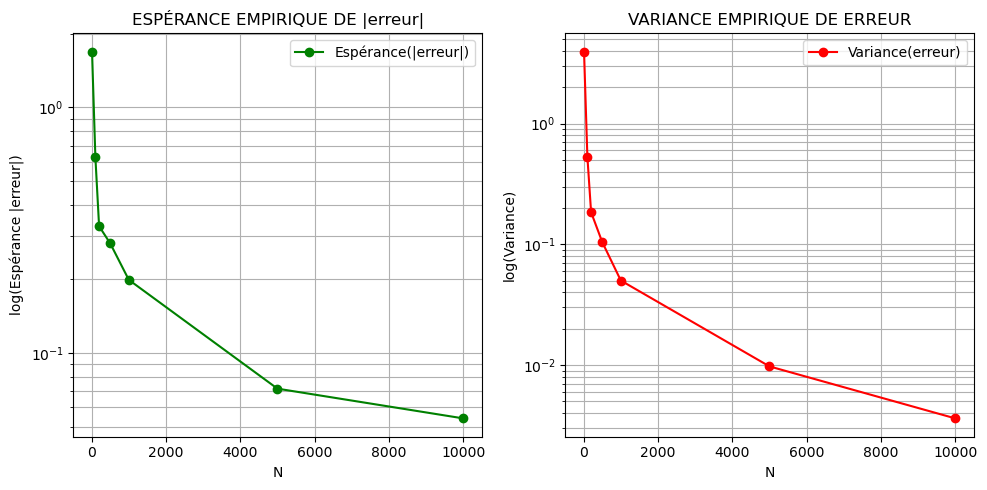

Valeurs de N : [10, 100, 200, 500, 1000, 5000, 10000]
Espérance empirique de abs(erreur) :  [1.687936933750759, 0.6271889771014727, 0.3284721066734688, 0.2794070814922896, 0.19854899023977823, 0.07155659771663452, 0.05414846006135983]
Variance empirique de erreur :  [3.9331450111814803, 0.5311277008495131, 0.1843147831401599, 0.10433131853146178, 0.05010550023299898, 0.009752127091624962, 0.003619828187218479]


In [8]:
####################### ÉTUDE DE LA CONVERGENCE DE L'ERREUR DE RÉPLICATION #########################
####################### ÉTUDE DES MOMENTS DE L'ERREUR DE RÉPLICATION ###############################    
    
# on s'intéresse à la convergence de la stratégie en étudiant l'erreur de réplication
# Pour chaque valeur de N, on simule M variables aléatoires erreur(N) grâce à simulation
# On considère ensuite la variance empirique en l'espérance empirique de cette erreur(N)   
# On représente l'évolution de l'espérance de la valeur absolue et de la variance avec N
# On travaille en échelle semi-log pour montrer une décroissance en 1/N^alpha

np.random.seed(4)

def analyse_erreur_replication(M, liste_N):
    
    variances = []
    esperances_abs = []

    for N in liste_N:
        erreurs = []

        for nb in range(M):
            para, para, para, para, erreur = simulation_portefeuille(N)
            erreurs.append(erreur)

        # Calcul de la variance et de l'espérance de la valeur absolue
        variance = np.var(erreurs)
        esperance_abs = np.mean(np.abs(erreurs))

        variances.append(variance)
        esperances_abs.append(esperance_abs)

    # Tracé en semi-log : N linéaire, espérance et variance en log
    plt.figure(figsize=(10, 5))

    # Espérance de |erreur|
    plt.subplot(1, 2, 1)
    plt.semilogy(liste_N, esperances_abs, marker='o', color='green', label='Espérance(|erreur|)')
    plt.title("ESPÉRANCE EMPIRIQUE DE |erreur|")
    plt.xlabel("N")
    plt.ylabel("log(Espérance |erreur|)")
    plt.grid(True, which="both")
    plt.legend()

    # Variance de l'erreur
    plt.subplot(1, 2, 2)
    plt.semilogy(liste_N, variances, marker='o', color='red', label='Variance(erreur)')
    plt.title("VARIANCE EMPIRIQUE DE ERREUR")
    plt.xlabel("N")
    plt.ylabel("log(Variance)")
    plt.grid(True, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("Valeurs de N :", liste_N)
    print("Espérance empirique de abs(erreur) : ", esperances_abs)
    print("Variance empirique de erreur : ", variances)

analyse_erreur_replication(10, [10,100,200,500,1000,5000,10000])

Numériquement, on observe bien que $\hat{\mathbb{E}}_N \xrightarrow[ N \to +\infty]{} 0$ et $\hat{\mathbb{V}}_N \xrightarrow[ N \to +\infty]{}0$.

D'ailleurs, en passant en échelle log-log au lieu de semi-log, on met en évidence une décroissance de la forme $1/N^{\alpha}$. 

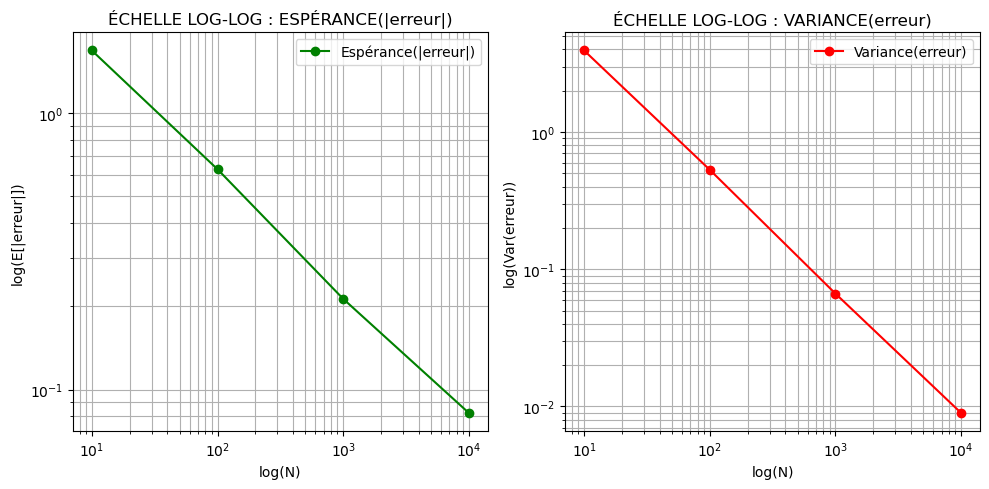

In [9]:
np.random.seed(4)

def analyse_erreur_replication(M, liste_N):
    variances = []
    esperances_abs = []

    for N in liste_N:
        erreurs = []

        for nb in range(M):
            para, para, para, para, erreur = simulation_portefeuille(N)
            erreurs.append(erreur)

        # Calcul de la variance et de l'espérance de la valeur absolue
        variance = np.var(erreurs)
        esperance_abs = np.mean(np.abs(erreurs))

        variances.append(variance)
        esperances_abs.append(esperance_abs)

    # Tracé en échelle log-log
    plt.figure(figsize=(10, 5))

    # Espérance de |erreur|
    plt.subplot(1, 2, 1)
    plt.loglog(liste_N, esperances_abs, marker='o', color='green', label='Espérance(|erreur|)')
    plt.title("ÉCHELLE LOG-LOG : ESPÉRANCE(|erreur|)")
    plt.xlabel("log(N)")
    plt.ylabel("log(E[|erreur|])")
    plt.grid(True, which="both")
    plt.legend()

    # Variance de l'erreur
    plt.subplot(1, 2, 2)
    plt.loglog(liste_N, variances, marker='o', color='red', label='Variance(erreur)')
    plt.title("ÉCHELLE LOG-LOG : VARIANCE(erreur)")
    plt.xlabel("log(N)")
    plt.ylabel("log(Var(erreur))")
    plt.grid(True, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()

analyse_erreur_replication(10, [10,100,1000, 10000])

Commentaires additionnels

Cela met en évidence une décroissance qui serait **empiriquement** de la forme :
$\boxed{\mathbb{E}\left[ \left| \Delta_T^h \right|\right] \propto N^{-1/3}}$ et $\boxed{\mathbb{V}\left[ \Delta_T^h \right] \propto N^{-2/3}}$.

Toutefois, cela ne suffirait pas à conclure formellement que $\Delta_T^h \xrightarrow[ N \to +\infty]{p.s.} 0$. 

En effet, on aimerait appliquer le lemme de Borel-Cantelli :
Soit $\epsilon > 0$. Considérons $\mathbb{P}(\left| \Delta_T^h \right| \geq \epsilon)$. 
D'après l'inégalité de Bienaymé-Tchebychev, on aurait (à l'espérance de $\Delta_T^h$ près) $\mathbb{P}(\left| \Delta_T^h \right| \geq \epsilon) \leq \frac{\mathbb{V}\left[ \Delta_T^h \right]}{\epsilon^2} \sim \frac{1}{\epsilon^2 n^{2/3}}$. Ce n'est pas le terme d'une série convergente, et on ne peut donc pas conclure par cet argument.

On se contente donc d'une mise en évidence numérique de la convergence p.s. de $\Delta_T^h$. 

Une autre manière de visualiser ce phénomène est d'étudier la distribution des variables aléatoires réelles $\Delta_T^{h, i}$ et de faire augmenter $N$. On obtient une répartition qui *ressemble* à un gaussienne. 

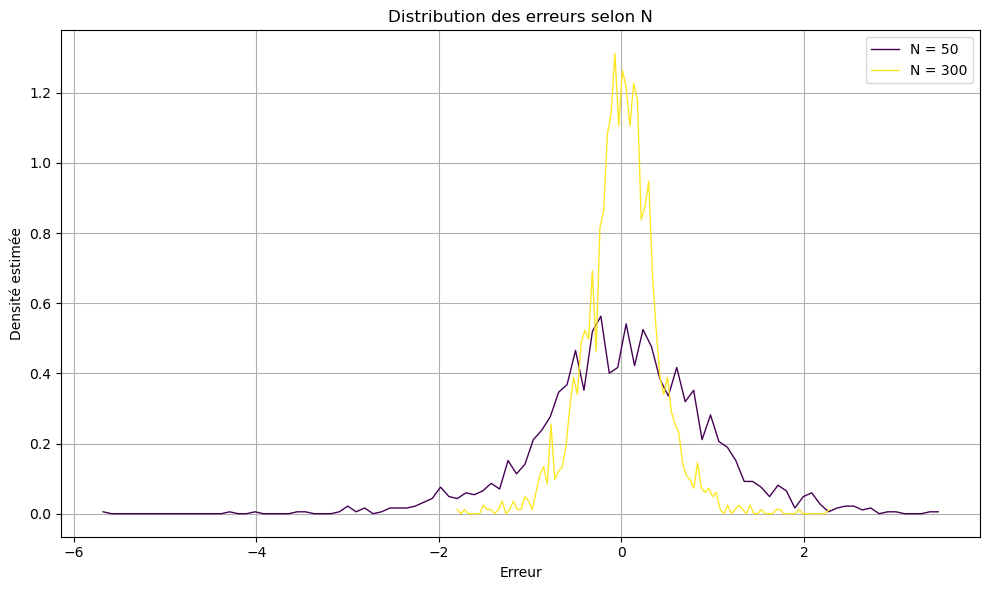

In [10]:
######################### DISTRIBUTION ASYMPTOTIQUE DE L'ERREUR DE RÉPLICATION ###########################
######################### ÉVOLUTION DE LA DISTRIBUTION AVEC N ############################################    

np.random.seed(4)

# À N fixé, on génère M trajectoires et on récupère l'erreur
# On s'intéresse à la distribution de l'erreur
def distribution_erreur(M, liste_N):
    plt.figure(figsize=(10, 6))
    couleurs = plt.cm.viridis(np.linspace(0, 1, len(liste_N)))

    for i, N in enumerate(liste_N):
        erreurs = []

        for _ in range(M):
            _, _, _, _, erreur = simulation_portefeuille(N)
            erreurs.append(erreur)

        erreurs = np.array(erreurs)

        # Calcul de la densité via un histogramme normalisé
        nb_bins = 100
        densité, bords = np.histogram(erreurs, bins=nb_bins, density=True)
        centres = (bords[:-1] + bords[1:]) / 2  # Milieux des intervalles

        # Tracé en courbe lisse
        plt.plot(centres, densité, label=f"N = {N}", color=couleurs[i], linewidth=1)

    plt.title("Distribution des erreurs selon N")
    plt.xlabel("Erreur")
    plt.ylabel("Densité estimée")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
distribution_erreur(2000, [50, 300])    

Comme prévu, la distribution est centrée autour de 0 et se resserre avec $N$. On ne propose pas de valeur de $N > 300$, car le pic devient trop haut et empèche de visualiser correctement le phénomène.



En gardant le même *call*, on calcule désormais différement son *delta* : au lieu de déterminer son expression analytique exacte, on va en déterminer une expression approchée via la méthode de Monte-Carlo

L'idée est la suivante, nous détaillerons ensuite sa construction pratique : on approche le delta par un taux d'accroissement. Cela demande donc d'estimer la valeur actualisée du call pour un prix du sous-jacent très légèrement différent. Pour cela, on simule un grand nombre de trajectoires, et on prend la moyenne empirique du prix du call pour ces trajectoires (rappelons que le prix du call est le payoff actualisé). 

Pour cette stratégie, il faudra porter un soin particulier au choix de certains paramètres : 
- choix de l'estimateur du *delta* (taux d'accroissement centré ou décentré) pour obtenir un estimateur sans biais
- choix du pas dans le taux d'accroissement
- choix du nombre de trajectoires simulées

Entrons donc dans le vif du sujet et construisons cet estimateur. On appliquera cette nouvelle stratégie numériquement. On peut raisonablement espérer obtenir un comportement qualitatif proche de celui obtenu en (à condition de bien choisir les paramètres), en particulier sur la convergence de l'erreur de réplication vers $0$.

Rappelons avant toute chose que l'on souhaite construire un estimateur de $\partial_y v(t_i, y)$.

Soit $\epsilon > 0$ : on a $\partial_y v(t_i, y) \approx \frac{v(t_i, y+\epsilon) - v(t_i, y-\epsilon)}{2 \epsilon}$ pour $\epsilon$ suffisament petit.

Par ailleurs, $v(t_i, y + \epsilon) = e^{-r(T-t_i)} \mathbb{E}^{\mathbb{Q}} \left[ (S_T - K)^+ | S_{t_i} = y + \epsilon \right] = e^{-r(T-t_i)} \mathbb{E}^{\mathbb{Q}} \left[ (\tilde{S}_T(y+\epsilon) - K)^+ \right]$ où $\tilde{S}_T(y+\epsilon)$ est une trajectoire de Black-Scholes d'un call de mêmes paramètres, de valeur initiale $y + \epsilon$ et de maturité $T - t_i$. 

On peut donc naturellement remplacer $\mathbb{E}^{\mathbb{Q}} \left[ (\tilde{S}_T(y + \epsilon) - K)^+ \right]$ par son estimateur sans biais (l'espérance empirique) qui est $\frac{1}{M} \sum_{j=1}^{M} (\tilde{S}_T^j(y + \epsilon) - K)^+$ avec $M$ qui sera le nombre de trajectoies aléatoires. 

Ainsi, en raisonnant de la même manière sur $v(t_i, y + \epsilon)$, on obtient finalement un **estimateur du *delta*** que l'on va commenter :

$$\boxed{\hat{\delta_y}^M v(t_i, y) := \frac{e^{-r(T-t_i)}}{2M\epsilon} \sum_{j=1}^{M} \left[(\tilde{S}_T^j(y + \epsilon) - K)^+ - (\tilde{S}_T^j(y - \epsilon) - K )^+ \right]}$$

On rappelle que sous la probabilité risque neutre $\mathbb{Q}$, le sous-jacent a l'évolution $S_{t_i} = S_0 \exp\left[ \left( r - \frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} \sum_{j=1}^{i} N_j \right]$ où les $N_j$ sont i.i.d de loi $\mathcal{N}_{\mathbb{Q}}(0,1)$.

 Alors $S_T = S_{t_i} \exp\left[ \left( r - \frac{\sigma^2}{2}\right)(T-t) + \sigma \sqrt{h} \sum_{j=i+1}^{N} N_j \right]$. Mais $\sum_{j=i+1}^{N} N_j \sim \mathcal{N}(0, N-i) \sim \mathcal{N}\left(0, \frac{T-t}{h} \right)$.

 Ainsi, si on note $Z \sim \mathcal{N}_{\mathbb{Q}}(0,1)$, on a $\sigma \sqrt{h} \sum_{j=i+1}^{N} N_j \sim \sigma \sqrt{T-t} Z$ et donc $S_T = S_{t_i} \exp\left[ \left( r - \frac{\sigma^2}{2}\right)(T-t) +\sigma \sqrt{T-t} Z \right]$. Ainsi, pour générer une trajectoire, il suffit de générer une variable normale centrée réduite $Z$.

Détaillons le choix de cet estimateur :

- comme l'espérance empirique est sans biais, c'est un estimateur sans biais du taux d'accroissement centré de largeur $2\epsilon$, lequel est une bonne approximation du *delta* avec une précision en $O(\epsilon^2)$ par la formule de Taylor

- il s'agira de choisir correctement $\epsilon$ : s'il est trop grand, le taux d'accroissement s'éloigne du *delta*. S'il est trop petit, l'estimateur sera trop sensible à l'aspect aléatoire des simulations ! On peut choisir $\epsilon$ en fonction de $y$, en particulier on prendra dans la suite $\epsilon := 0.01 y$.

- l'intérêt de cet estimateur est le suivant : en regroupant dans la somme les trajectoires pour des valeurs initiales de $y-\epsilon$ et $y+\epsilon$, on peut simuler seulement $M$ lois normales (au lieu de $2M$) : en fait, les variables aléatoires gaussiennes seront les mêmes dans la trajectoire partant de $y + \epsilon$ et $y - \epsilon$ : cela permettra de réduire l'erreur d'estimation entre $v(t_i, y + \epsilon)$ et $ v(t_i, y - \epsilon)$.

- Le choix du nombre de trajectoires $M$ est la partie la plus délicate. Dans cette nouvelle approche, on accumule plusieurs erreurs : l'erreur de discrétisation, et l'erreur de Monte-Carlo (liée à l'estimation du *delta*), laquelle s'accumule d'ailleurs le long de la grille de discrétisation. Le théorème central limite (TCL) nous indique que l'erreur de Monte-Carlo au temps $t_i$ est en $1/\sqrt{M}$. Or, on accumule cette erreur dans le temps, pour chacun des $N$ instants, donc l'erreur est multipliée par un facteur $\sqrt{N}$. 
 En on montrera par ailleurs que l'erreur liée au pas de discrétisation est en $O(\sqrt{h} | \ln(h) |) = O(\ln(N)/\sqrt{N}$. 
 Or, il est raisonnable de souhaiter que l'erreur de Monte-Carlo ne perturbe pas la discrétisation : autrement dit, on veut que l'erreur de Monte-Carlo soit inférieure à l'erreur de discrétisation, c'est pourquoi on souhaite avoir $\sqrt{N} / \sqrt{M} \leq \ln(N)/\sqrt{N}$, soit $M \geq \frac{N^2}{\ln(N)^2}$.
 Dans la suite, on choisit donc $\boxed{M := N^2}$, qui permet d'observer numériquement la convergence p.s de l'erreur de réplication.

On obtient donc finalement l'estimateur suivant : 

$$\boxed{\hat{\delta_y}^N v(t_i, S_{t_i}) := \frac{e^{-r(T-t_i)}}{2N^2\epsilon} \sum_{j=1}^{N^2} \left[(\tilde{S}_T^j(1.01 S_{t_i}) - K)^+ - (\tilde{S}_T^j(0.99 S_{t_i}) - K )^+ \right]}$$


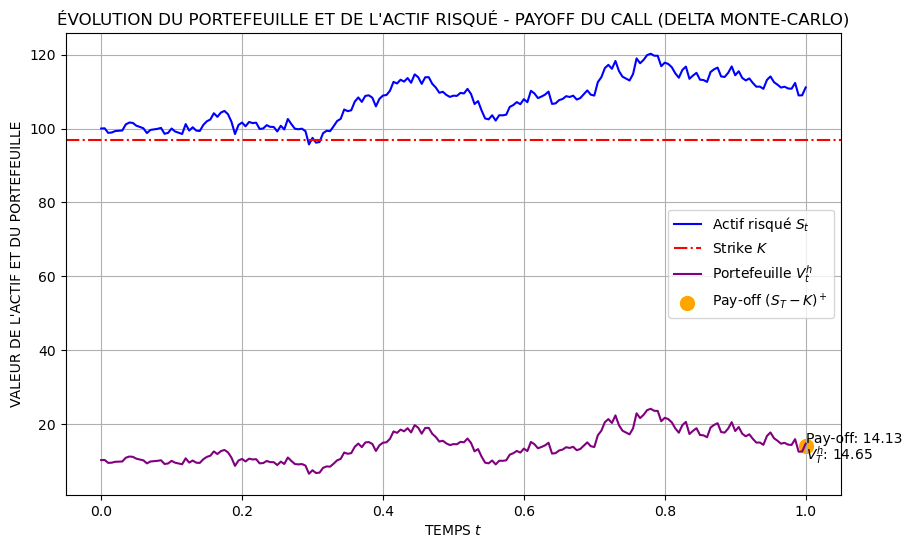

Valeur initiale du portefeuille : 10.210258529971682
Valeur finale du portefeuille : 14.646768053333446
Pay-off de l'option à maturité : 14.131192356527166
Erreur de réplication : 0.5155756968062803


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(4)

## Paramètres du modèle de Black-Scholes / paramètres de l'option
S0 = 100 
sigma = 0.2
mu = 0.03
r = 0.015
b = r - sigma * mu  
K = 97
T = 1
liste_N = [10, 100, 500, 1000, 5000, 10000]

################# SIMULATION TRAJECTORIELLE DU PORTEFEUILLE ######################################
################# DELTA APPROCHÉ PAR MONTE CARLO ##########################################


# fonction pour estimer le delta par Monte-Carlo
def monte_carlo_delta(t_i, S_t_i, T, r, sigma, K, N):
    M = N**2  # Nombre de trajectoires Monte-Carlo
    epsilon = 0.01 * S_t_i  # epsilon = 0.01 * S_t_i (donc y + epsilon = 1.01 S_t_i, y - epsilon = 0.99 S_t_i)
    dt = T - t_i
    
    # Générer des nombres aléatoires pour les trajectoires - on travaille uniquement en vectoriel
    Z = np.random.normal(0, 1, M)
    
    # Simuler S_T pour y = S_t_i + epsilon et S_t_i - epsilon
    S_T_plus = (S_t_i + epsilon) * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    S_T_minus = (S_t_i - epsilon) * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    # Calculer les payoffs
    payoff_plus = np.maximum(S_T_plus - K, 0)
    payoff_minus = np.maximum(S_T_minus - K, 0)
    
    # Estimateur du delta
    delta = np.exp(-r * dt) * np.mean(payoff_plus - payoff_minus) / (2 * epsilon)
    
    return delta

# simulation trajectorielle du portefeuille
def simulation_portefeuille_MC(N):
    h = T / N
    t = np.linspace(0, T, N + 1)  # Grille temporelle
    S = np.zeros(N + 1)  # Trajectoire de l'actif risqué
    V = np.zeros(N + 1)  # Valeur du portefeuille
    deltas = np.zeros(N + 1)  # Quantités d'actif risqué

    # Initialisation
    S[0] = S0
    # Valeur initiale du portefeuille : prix Black-Scholes exact
    M1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    M2 = M1 - sigma * np.sqrt(T)
    V[0] = S0 * norm.cdf(M1) - K * np.exp(-r * T) * norm.cdf(M2)  # Prix initial de l'option
    deltas[0] = norm.cdf(M1)  # Delta initial exact (optionnel, peut être remplacé par Monte-Carlo)
    # mais comme on a déjà calculé M1, autant utiliser le delta exact

    # Simuler la trajectoire et mettre à jour le portefeuille
    for i in range(N):
        # Partie aléatoire de l'actif risqué
        N_i = np.random.normal(0, 1)
        
        # Évolution de Black-Scholes
        S[i + 1] = S[i] * np.exp(sigma * np.sqrt(h) * N_i + (b - 0.5 * sigma**2) * h)
        
        # Calcul du delta par Monte-Carlo
        if t[i] < T - 1e-6:  # Éviter t = T
            deltas[i] = monte_carlo_delta(t[i], S[i], T, r, sigma, K, N)
        else:
            deltas[i] = 0
        
        # Calcul de delta0_i (quantité d'actif sans risque détenue)
        S0_i = np.exp(r * t[i])  # Valeur de l'actif sans risque à t_i
        delta0_i = (V[i] - deltas[i] * S[i]) / S0_i
        
        # Mise à jour de la valeur du portefeuille à t_{i+1}
        S0_ip1 = np.exp(r * t[i + 1])
        V[i + 1] = deltas[i] * S[i + 1] + delta0_i * S0_ip1
        
        # Delta pour le dernier pas
        if t[i + 1] < T - 1e-6:
            deltas[i + 1] = monte_carlo_delta(t[i + 1], S[i + 1], T, r, sigma, K, N)
        else:
            deltas[i + 1] = 0

    payoff = np.maximum(S[-1] - K, 0)
    erreur = V[-1] - payoff

    return t, S, V, payoff, erreur


def trace_portefeuille_MC(N):
    t, S, V, payoff, erreur = simulation_portefeuille_MC(N)

    plt.figure(figsize=(10, 6))
    
    # Actif risqué
    plt.plot(t, S, label='Actif risqué $S_t$', color='blue')
    
    # Strike
    plt.axhline(y=K, label='Strike $K$', color='red', linestyle='-.')
    
    # Portefeuille
    plt.plot(t, V, label='Portefeuille $V_t^h$', color='purple')
    
    # Pay-off à maturité
    plt.scatter([T], [payoff], label='Pay-off $(S_T - K)^+$', color='orange', marker='o', s=100)
    
    # Annotations
    plt.text(T, payoff, f'Pay-off: {payoff:.2f}', verticalalignment='bottom')
    plt.text(T, V[-1], f'$V_T^h$: {V[-1]:.2f}', verticalalignment='top')
    
    # Configuration du graphique
    plt.xlabel('TEMPS $t$')
    plt.ylabel('VALEUR DE L\'ACTIF ET DU PORTEFEUILLE')
    plt.title('ÉVOLUTION DU PORTEFEUILLE ET DE L\'ACTIF RISQUÉ - PAYOFF DU CALL (DELTA MONTE-CARLO)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Afficher les résultats finaux
    print("Valeur initiale du portefeuille : " + str(V[0]))
    print("Valeur finale du portefeuille : " + str(V[-1]))
    print("Pay-off de l'option à maturité : " + str(payoff))
    print("Erreur de réplication : " + str(V[-1] - payoff))
    
    
trace_portefeuille_MC(200)    

On observe bien le même comportement qualitatif, en particulier il y a bien convergence du portefeuille vers le payoff du call. On peut s'intéresser de nouveau à la répartition de l'erreur selon $N$, comme fait précédement sur la méthode *delta*-exact. 

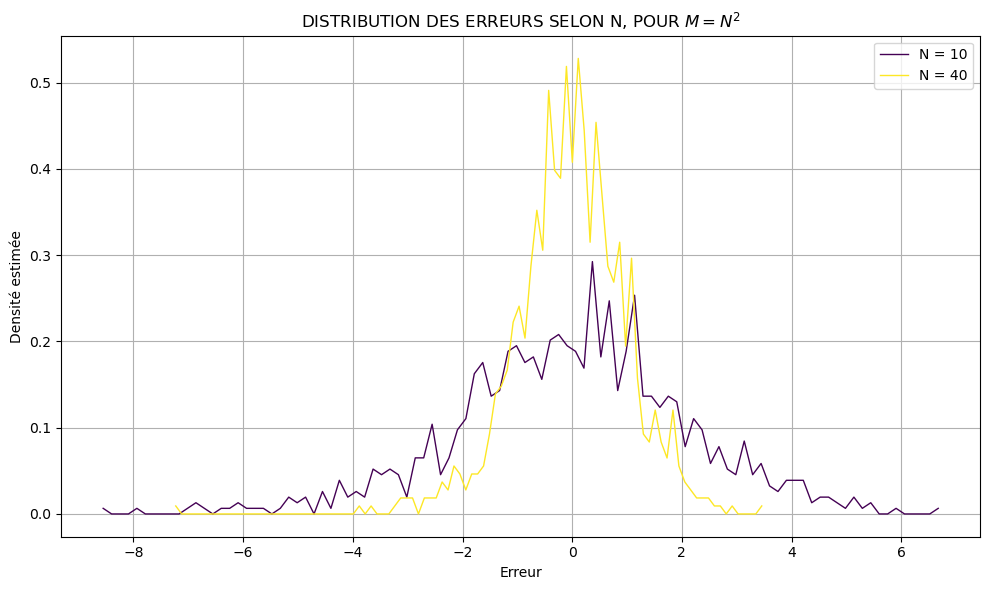

In [17]:
######################### DISTRIBUTION ASYMPTOTIQUE DE L'ERREUR DE RÉPLICATION ###########################
######################### ÉVOLUTION DE LA DISTRIBUTION AVEC N ############################################ 
######################### DELTA-MONTE CARLO - CALL CLASSIQUE #############################################   

np.random.seed(4)

# À N fixé, on génère K trajectoires et on récupère l'erreur
# On s'intéresse à la distribution de l'erreur
def distribution_erreur_MC(K, liste_N):
    plt.figure(figsize=(10, 6))
    couleurs = plt.cm.viridis(np.linspace(0, 1, len(liste_N)))

    for i, N in enumerate(liste_N):
        erreurs = []

        for _ in range(K):
            _, _, _, _, erreur = simulation_portefeuille_MC(N)
            erreurs.append(erreur)

        erreurs = np.array(erreurs)

        # Calcul de la densité via un histogramme normalisé
        nb_bins = 100
        densité, bords = np.histogram(erreurs, bins=nb_bins, density=True)
        centres = (bords[:-1] + bords[1:]) / 2  # Milieux des intervalles

        # Tracé en courbe lisse
        plt.plot(centres, densité, label=f"N = {N}", color=couleurs[i], linewidth=1)

    plt.title("DISTRIBUTION DES ERREURS SELON N, POUR $M = N^2$")
    plt.xlabel("Erreur")
    plt.ylabel("Densité estimée")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
distribution_erreur_MC(1000, [10, 40])

Nous examinons la convergence de $\Delta_T^h$.

*Nous laissons cette preuve de convergence ouverte et esquissons ci-dessous les principales pistes (contrôle du moment d'ordre 2, lemme de Gronwall discret).*

Il s'agit tout d'abord de montrer que $sup_{i \in \left[ 0, N \right]} \mathbb{E} \left[ \left| V_{t_i}^h \right|^2 \right] < + \infty$.

Pour cela, on introduit un temps d'arrêt dans le processus : $\tau_M := \inf \left\{ i \geq 0 : \left| V_{t_i}^h \right| \geq M \right\}$ et on considère $\mathbb{E} \left[ \left| V_{t_i \wedge \tau_M}^h \right|^2 \right]$.

En considérant le processus auquel est soumis $S_{t_i}$ et les conditions sur le portefeuille (autofinancement), on découpe $V_{t_i \wedge \tau_M}^h$. On fait ensuite apparaître une somme dans cette expression, et grâce à des inégalités (de Cauchy-Schwarz dans les sommes notamment), on peut faire apparaître une inégalité entre $V_{t_i \wedge \tau_M}^h$ et $V_{t_{i+1} \wedge \tau_M}^h$. Comme nous n'avons pas réussi proprement cette partie, nous n'avons pas la forme exacte de l'inégalité. Mais évoquons quel peut être l'usage du lemme de Gronwall ici.

Le lemme de Gronwall discret s'énonce ainsi : 

Si $u_{n+1} \leq a u_n + b$, alors $u_n \leq a^n u_0 + b \frac{a^n - 1}{a - 1}$ (si $a \neq 1$). 

Ici, on pourra obtenir une majoration uniforme du moment d'ordre 2 de $V_{t_i \wedge \tau_M}^h$ (uniforme dans le sens où cette majoration ne dépendra pas de $M$).

Puis il s'agira d'utiliser le lemme de Fatou pour conclure et éliminer le temps d'arrêt, car 
$\mathbb{E} \left[ \liminf \left| V_{t_i \wedge \tau_M}^h \right|^2 \right] = \mathbb{E} \left[ \liminf \left| V_{t_i}^h \right|^2 \right]$, et donc la majoration sur le premier terme, qui est conservée avec le lemme de Fatou, permet de conclure que $sup_{i \in \left[ 0, N \right]} \mathbb{E} \left[ \left| V_{t_i}^h \right|^2 \right] < + \infty$.



**Intéressons nous à présent à l'encadrement des dérivées partielles** $ \partial_t^{\alpha} \partial_y^{\beta} v(t, y)$

Suivant l'indication donnée, on s'intéresse à la recherche d'une densité pertinente $p_y(t, z)$. Rappelons tout d'abord que : 

\begin{align*}
C_{K,T}(t,y)
&= e^{-r\,(T-t)}\;
\mathbb{E}^{\mathbb{Q}}\Bigl[\bigl(y\,\exp\bigl((r-\tfrac{\sigma^2}{2})(T-t)
+\sigma\sqrt{T-t}\,\overline N_1\bigr)-K\bigr)^+\Bigr] \\ &= \exp(-r(T-t))\int_{-\infty}^{+\infty} \phi\left(y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t) + \sigma \sqrt{T-t} u\right)\right) \frac{1}{\sqrt{2 \pi}} \exp\left(-\frac{u^2}{2} \right)du 
\end{align*}

Dans l'optique de faire apparaitre une densité pertinente et une fonction $f$ comme suggéré dans l'étude, on souhaite définir f comme une composée de $\phi$. Cela impose par un changement de variable judicieux d'éliminer les dépendances en $y$ et $t$ de $\phi$.

Deux options s'offrent à nous : 

- on peut effectuer le changement de variable légitime : $ z = y\exp\left(\left(r-\frac{\sigma^2}{2}\right)(T- t) + \sigma \sqrt{T-t} u\right)$, avec $\frac{dz}{du} = \sigma \sqrt{T-t} z$, ce qui implique : 

$$C_{K,T}(t,y) = \exp(-r(T-t))\int_{0}^{+\infty} \phi\left(z\right) \frac{1}{z \sigma \sqrt{2 \pi (T-t)}} \exp\left(-\frac{\left(\ln(z) - m(t,y)\right)^2}{2 \sigma^2 (T-t)} \right)dz $$ 

où on a posé $m(t,y) = \ln y + \left( r - \frac{\sigma^2}{2} \right)(T - t)$. Cela nous permet de faire apparaitre la densité d'une loi log-normale, de densité de probabilité : $$p_y(t,z) = \frac{1}{z \sigma \sqrt{2 \pi (T - t)}} \exp \left( - \frac{(\ln z - m(t,y))^2}{2 \sigma^2 (T - t)} \right)$$ L'intérêt est que cette densité est régulière, à dérivée intégrable sur $\mathbb{R}$, puisque les dérivées d'une loi normale le sont et qu'$X$ suit une loi log-normale si et seulement si $\ln(X)$ suit une loi normale. On en déduit que les indications suggérées s'appliquent. Pour autant, les manipulations de dérivées partielles sont particulièrement fastidieuses pour une telle densité du fait de la double dépendance en t et le $ln(y)$.

- les calculs de dérivées partielles de la densité log-normale étant fastidieux et peu concluant, on réécrit $C_{K,T}$ via l'indication du problème, en faisant apparaitre le noyau de la chaleur, $p(t, x) = \frac{1}{\sqrt{2\pi \sigma^2 t}} \exp\left( -\frac{x^2}{2 \sigma^2 t} \right)$. Ainsi : $$v(t, y) = e^{-r(T-t)} \int_0^{+\infty} \Phi(z) \, p_y(t, z) \, dz 
= e^{-r(T-t)} \int_{\mathbb{R}} \Phi(e^u) \, p(T-t, u - u_0) \, du$$ 

où $u_0 = \ln y + \left( r - \frac{\sigma^2}{2} \right)(T - t)$. Pour autant, les multiples dépendances des dérivées empêchent les résultats d'aboutir clairement à un résultat similaire à celui du problème. On comprend néanmoins bien la forme du résultat souhaitée, dont nous allons expliquer la cohérence : 

- $\phi$ est 1-Lipschitzienne (en raisonnant directement cas-par-cas), ie : $ \quad \forall x, y \in \mathbb{R}, |\Phi(x) - \Phi(y)| \leq [\phi]_1|x - y|$.

- En utilisant un bon $z_0$, on obtient la convergence des intégrales des dérivées partielles au niveau de leur point de non intégrabilité grâce à $\phi$.

- Lorsqu'on dérive par rapport au temps, on remarque que la dérivé selon t de la densité gaussienne se fait en deux temps : d'une part la dérivation de la constante de normalisation, et d'autre part celle de l'exponentielle. Ces deux termes font apparaitre au dénominateur un terme en $(T-t)$ ; le premier terme n'a pas d'autre action, là où le second fait apparaitre des terme en $(u-u_0)^n$ au numérateur. On est alors ramené au calcul de terme de moment d'ordre 1 ou 2, qui font sortir un terme en exponentielle de $u_0$ par changement de variables, faisant apparaitre le deuxième terme en $y$ souhaité, d'où le $(1+y)$ attendu en sommant les deux termes. On donne ici la dérivée selon t pour s'en convaincre : $\frac{\partial}{\partial t} p(T-t, u - u_0) = \left( \frac{1}{2(T-t)} - \frac{(u-u_0)^2}{2\sigma^2 (T-t)^2} + \left( r - \frac{\sigma^2}{2} \right) \frac{(u-u_0)}{\sigma^2 (T-t)} \right) p(T-t, u-u_0) $ 

- Lorsqu'on dérive par rapport à $y$, on fait apparaitre $y$ au dénominateur autant de fois qu'on dérive du $ln(y)$ ; on fait également apparaitre un terme en $\sqrt{T-t}$. On peut s'en convaincre en reprenant les expressions obtenues en 



**Majoration de** $\mathbb{E}\left[|\Delta_h^T|\right]$

On souhaite démontrer que $\mathbb{E}\left[|\Delta_h^T|\right] \leq C h^{\frac{1}{2}} (1 + x) |\ln(h)|$. Les pistes considérées pour aboutir à ce résultat ne nous on pas permis de conclure. La première idée était d'écrire : 

$$\Delta_h^T := V_h^T - \Phi(S_T) = \sum_{i=1}^{N-1} \left( V_{t_{i+1}}^h - V_{t_i}^h - v(t_{i+1},S_{t_{i+1}}) + v(t_{i},S_{t_i})\right)$$

et de diviser en deux cette. Pour la première somme, on repart de l'expression $(P)$: 

$$\sum_{i=1}^{N-1} \left( V_{t_{i+1}}^h - V_{t_i}^h \right) = \sum_{i=1}^{N-1}
\delta_{t_i} (S_{t_{i+1}} - S_{t_i}) + \delta_{t_i}^{0} (S_{t_{i+1}}^0 - S_{t_i}^0) = \sum_{i=1}^{N-1} (S_{t_{i+1}} - S_{t_i})\partial_y v(t_i, S_{t_i}) + (\exp(rh)-1)(V_{t_i}^h - \partial_y v(t_i, S_{t_i})S_{t_i})
$$

Pour la seconde, on utilise $(5.5)$ : 

$$\sum_{i=1}^{N-1} v(t_{i+1},S_{t_{i+1}}) - v(t_{i},S_{t_i}) = \sum_{i=1}^{N-1}
\partial_y v(t_i, S_{t_i}) (S_{t_{i+1}} - S_{t_i}) + \left( v(t_i, S_{t_i}) - S_{t_i} \, \partial_y v(t_i, S_{t_i}) \right) r h + \widetilde{R}_i^h
$$

Ceci parait à priori pertinent, car on est en mesure d'encadrer l'espérance des termes de ces deux sommes, et puisqu'on a fait apparaitre les termes $(S_{t_{i+1}} - S_{t_i})$ qu'on sait estimer via la formule qu'on vient de démontrer. En épargnant le lecteur des calculs fatidieux, on aboutit à l'encadrement : $\mathbb{E}\left[|S_{t_{i+1}} - S_{t_i}|\right]\leq Cx\sqrt{h}\exp(bh)$ pour h suffisamment grand. Or, ce terme,une fois sommée entre $1$ et $N$, va donc donner un terme en $\frac{1}{\sqrt{h}}$, qui diverge, rendant donc cette première méthode inutile.

Nénamoins, on garde espoir en remarquant que ce terme est présent dans les deux sommes et se substitue donc, impliquant qu'il n'a aucune contribution pour le résultat final. Pour autant, les termes restants dans les deux sommes ne nous arrange pas : les encadrements grossiers donnent une majoration troplarge, et si on est tenté d'exploiter que $\sup_{i \in \{0, \dots, N\}} \mathbb{E}\left[|V_h(t_i)|^2\right] < +\infty$, la majoration sur le terme de la première somme en $V_h(t_i) $ est insuffisante. 

Il nous aura fallu trouver une manière plus maligne de raisonner sur $\Delta_h^T$, que peut nous suggérer le terme final en $|\ln(h)|$ : un tel terme n'apparaissant nullement dans l'ensemble des résultats démontrés dans ce sujet, on devine qu'il correspond sûrement à un équivalent d'une somme de type harmonique de terme de la forme $\frac{1}{N-i} = \frac{h}{T-t_i}$. 



Nous transposons notre étude pour un nouveau type de *payoff* : désormais, $\Phi(y) = \mathbb{I}_{y>K}$. On s'intéresse à la convergence de la stratégie *delta* pour ce type d'option.

Dans un premier temps, déterminons $C_{K,T}(t,y) = \exp(-r(T-t)) \mathbb{E}^{\mathbb{Q}}\left[ \mathbb{I}_{S_T > K} | S_t = y\right]$.

- On rappelle que sous la probabilité risque neutre $\mathbb{Q}$, le sous-jacent a l'évolution $S_{t_i} = S_0 \exp\left[ \left( r - \frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} \sum_{j=1}^{i} N_j \right]$ où les $N_j$ sont i.i.d de loi $\mathcal{N}_{\mathbb{Q}}(0,1)$.

 Alors $\frac{S_T}{S_t} = \frac{S_T}{y} = \exp\left[ \left( r - \frac{\sigma^2}{2}\right)(T-t) + \sigma \sqrt{h} \sum_{j=i+1}^{N} N_j \right]$.

 Mais $\sum_{j=i+1}^{N} N_j \sim \mathcal{N}(0, N-i) \sim \mathcal{N}\left(0, \frac{T-t}{h} \right)$.

 Ainsi, si on note $Z \sim \mathcal{N}_{\mathbb{Q}}(0,1)$, on a $\sigma \sqrt{h} \sum_{j=i+1}^{N} N_j \sim \sigma \sqrt{T-t} Z$ et donc $S_T = y \exp\left[ \left( r - \frac{\sigma^2}{2}\right)(T-t) +\sigma \sqrt{T-t} Z \right]$.

 Alors $\mathbb{E}^{\mathbb{Q}}\left[ \mathbb{I}_{S_T > K} | S_t = y\right] = \mathbb{Q} \left[ y \exp\left[ \left( r - \frac{\sigma^2}{2}\right)(T-t) +\sigma \sqrt{T-t} Z \right] > K \right]$.

- Or $\ln\left( \frac{S_T}{y} \right) = \left( r - \frac{\sigma^2}{2} \right)(T-t) +\sigma \sqrt{T-t} Z $.

 Donc $\left\{ S_T > K \right\} = \left\{ \ln \left( \frac{S_T}{y} \right) > \ln \left( \frac{K}{y} \right) \right\} = \left\{ Z > \frac{ \ln \left( \frac{K}{y} \right) - \left( r - \frac{\sigma^2}{2} \right)(T - t) }{ \sigma \sqrt{T - t} } \right\}$.

- Si on note 
$$\gamma := \frac{ \ln \left( \frac{y}{K} \right) + \left( r - \frac{\sigma^2}{2} \right)(T - t) }{\sigma \sqrt{T - t} }$$

 on a donc $\mathbb{Q}\left[S_T > K | S_t = y \right] = \mathbb{Q}(Z > - \gamma) = 1 - \mathbb{Q}(Z < - \gamma) = 1 - F_{\mathcal{N}}(-\gamma) = F_{\mathcal{N}}(\gamma)$ par parité de la densité normale centrée réduite. 

Ainsi, on obtient finalement l'expression de la valeur de l'option au temps $t$ :

$$\boxed{\left\{
\begin{array}{ll}
C_{K,T}(t,y) = e^{-r(T-t)} F_{\mathcal{N}}(\gamma)\\
\text{avec } \gamma := \frac{ \ln \left( \frac{y}{K} \right) + \left( r - \frac{\sigma^2}{2} \right)(T - t) }{\sigma \sqrt{T - t} }
\end{array}
\right.}$$

On adapte le code précédent pour prendre en compte la modification du payoff. On considère d'abord une stratégie delta-exact.

Pour cela, il faut également calculer le nouveau *delta*.
On rappelle que l'on prend $\delta_{t_i} := \partial_y v(t_i, S_{t_i})$ où $v(t_i, S_{t_i}) = C_{K,T}(t_i, S_{t_i})$.

En dérivant par rapport au prix du sous-jacent, on trouve aisément 

$$\boxed{\delta_{t_i} = \frac{e^{-r(T-t_i)} F_{\mathcal{N}}(\gamma)}{S \sigma \sqrt{T-t_i}}}$$

On garde les mêmes paramètres du call de la question (maturité, strike, paramètre de tendance, volatilité, valeur initiale). 

Pour visualiser correctement la valeur du portefeuille (qui doit rester proche de $0$ et $1$), on introduit un double axe.

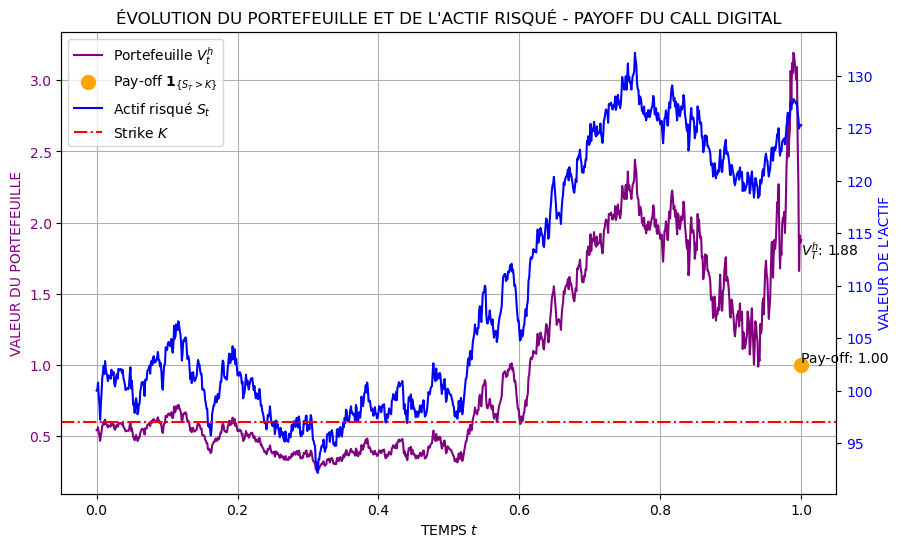

Valeur initiale du portefeuille : 0.5424488866885657
Valeur finale du portefeuille : 1.8793412626562542
Pay-off de l'option à maturité : 1
Erreur de réplication : 0.8793412626562542


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(8)

## paramètres du modèle de Black-Scholes / paramètres de l'option
S0 = 100 
sigma = 0.2
mu = 0.03
r = 0.015
b = r - sigma*mu
K = 97
T = 1
liste_N = [10, 100, 500, 1000, 5000, 10000]

################# SIMULATION TRAJECTORIELLE DU PORTEFEUILLE ######################################
################# ESTIMATION DE L'ERREUR DE RÉPLICATION ##########################################
################# PAYOFF 1(S_T > K) ##############################################################

## on simule  l'évolution du portefeuille et de l'actif
def simulation_portefeuille_2(N):
    h = T / N
    t = np.linspace(0, T, N + 1)  # Grille temporelle
    S = np.zeros(N + 1)  # Trajectoire de l'actif risqué
    V = np.zeros(N + 1)  # Valeur du portefeuille
    deltas = np.zeros(N + 1)  # Quantités d'actif risqué

    # Initialisation
    S[0] = S0
    # Valeur initiale du portefeuille : valeur actualisée de l'option
    
    gamma0 = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    V[0] = np.exp(-r * T) * norm.cdf(gamma0) # Prix initial de l'option
    deltas[0] = np.exp(-r * T) * norm.cdf(gamma0) / (S[0] * sigma * np.sqrt(T))

    # Simuler la trajectoire et mettre à jour le portefeuille
    for i in range(N):
        # Partie aléatoire de l'actif risqué
        N_i = np.random.normal(0, 1)
        
        # Évolution de Black-Scholes
        S[i + 1] = S[i] * np.exp(sigma * np.sqrt(h) * N_i + (b - 0.5 * sigma**2) * h)
        
        # Calcul du delta pour la calibration du portefeuille
        # Le delta est différent de celui du call classique
        # On veut éviter le cas t == T. Comme ce sont des flottants, on ne peut pas tester l'égalité !
        # On met donc une condition un peu arbitraire t < T - 1e-6
        # Cette condition est suffisante pour les valeurs de N que l'on considère dans cette question
        if t[i] < T - 1e-6:
            gamma = (np.log(S[i] / K) + (r - 0.5 * sigma**2) * (T - t[i])) / (sigma * np.sqrt(T - t[i]))
            deltas[i] = norm.cdf(gamma) * np.exp(-r * (T-t[i]))/(S[i] * sigma*np.sqrt(T - t[i]))
        else:
            deltas[i] = 0
        
        # Calcul de delta0_i (quantité d'actif sans risque détenue)
        S0_i = np.exp(r * t[i])  # Valeur de l'actif sans risque à t_i
        delta0_i = (V[i] - deltas[i] * S[i]) / S0_i
        
        # Mise à jour la valeur du portefeuille à t_{i+1}
        S0_ip1 = np.exp(r * t[i + 1])
        V[i + 1] = deltas[i] * S[i + 1] + delta0_i * S0_ip1
        
        # Delta pour le dernier pas, avec la même condition arbitraire que plus haut
     
        if t[i + 1] < T - 1e-6:
            gamma = (np.log(S[i] / K) + (r - 0.5 * sigma**2) * (T - t[i + 1])) / (sigma * np.sqrt(T - t[i + 1]))
            deltas[i + 1] = norm.cdf(gamma) * np.exp(-r * (T-t[i + 1]))/(S[i + 1] * sigma*np.sqrt(T - t[i + 1]))
        else:
            deltas[i] = 0    

    
    payoff = 0
    if (S[-1] > K):
        payoff = 1
    erreur = V[-1] - payoff

    return t, S, V, payoff, erreur


def trace_portefeuille_2(N):
    t, S, V, payoff, erreur = simulation_portefeuille_2(N)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Axe y principal pour le portefeuille V_t^h
    ax1.plot(t, V, label='Portefeuille $V_t^h$', color='purple')
    ax1.scatter([T], [payoff], label='Pay-off $\\mathbf{1}_{\\{S_T > K\\}}$', color='orange', marker='o', s=100)
    ax1.set_xlabel('TEMPS $t$')
    ax1.set_ylabel('VALEUR DU PORTEFEUILLE', color='purple')
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True)

    # Axe y secondaire pour l'actif risqué S_t
    ax2 = ax1.twinx()
    ax2.plot(t, S, label='Actif risqué $S_t$', color='blue')
    ax2.axhline(y=K, label='Strike $K$', color='red', linestyle='-.')
    ax2.set_ylabel('VALEUR DE L\'ACTIF', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    # Annotations
    ax1.text(T, payoff, f'Pay-off: {payoff:.2f}', verticalalignment='bottom')
    ax1.text(T, V[-1], f'$V_T^h$: {V[-1]:.2f}', verticalalignment='top')

    # Titre et légende
    plt.title('ÉVOLUTION DU PORTEFEUILLE ET DE L\'ACTIF RISQUÉ - PAYOFF DU CALL DIGITAL')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

    plt.show()
    
    # Afficher les résultats finaux
    print("Valeur initiale du portefeuille : " + str(V[0]))
    print("Valeur finale du portefeuille : " + str(V[-1]))
    print("Pay-off de l'option à maturité : " + str(payoff))
    print("Erreur de réplication : " + str(V[-1] - payoff))
    
trace_portefeuille_2(1000)    

Pour estimer la qualité de la réplication, on s'intéresse de nouveau à la convergence de $\Delta_T^h := V_T^h - \Phi(S_T)$.

Comme précédement, pour différentes valeurs de $N$, on simule $M$ variables aléatoires $\Delta_T^{h,i}$.

À $N$ fixé, on considère ensuite l'espérance empirique de la valeur absolue de l'erreur : $\boxed{\hat{\mathbb{E}}_N := \frac{1}{N} \sum_{i=1}^{N} \left| \Delta_T^{h,i} \right|}$.
On considère également la variance empirique (biaisée) de ces variables aléatoires : $\boxed{\hat{\mathbb{V}}_N := \frac{1}{N} \sum_{i=1}^{N} \left( \Delta_T^{h,i} - \hat{\mathbb{E}}_N\right)^2}$.

On s'intéresse alors à l'évolution de $\hat{\mathbb{E}}_N$ et $\hat{\mathbb{V}}_N$ avec $N$. 

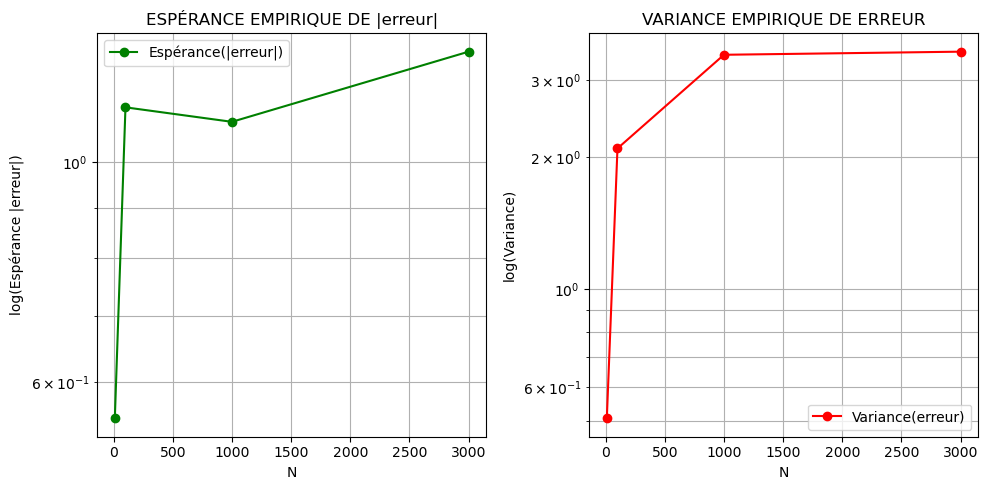

Valeurs de N : [10, 100, 1000, 3000]
Espérance empirique de abs(erreur) :  [0.5519916958480893, 1.1354905247840474, 1.0979414566350774, 1.2919216415047363]
Variance empirique de erreur :  [0.5081473667611056, 2.097300832597734, 3.429721813231313, 3.4861331323051923]


In [14]:
####################### ÉTUDE DE LA CONVERGENCE DE L'ERREUR DE RÉPLICATION #########################
####################### ÉTUDE DES MOMENTS DE L'ERREUR DE RÉPLICATION ###############################   

np.random.seed(8)
    
# on s'intéresse à la convergence de la stratégie en étudiant l'erreur de réplication
# Pour chaque valeur de N, on simule M variables aléatoires erreur(N) grâce à simulation
# On considère ensuite la variance empirique en l'espérance empirique de cette erreur(N)   
# On représente l'évolution de l'espérance de la valeur absolue et de la variance avec N
# On travaille en échelle semi-log pour montrer une décroissance en 1/N^alpha

def analyse_erreur_replication_2(M, liste_N):
    
    variances = []
    esperances_abs = []

    for N in liste_N:
        erreurs = []

        for nb in range(M):
            para, para, para, para, erreur = simulation_portefeuille_2(N)
            erreurs.append(erreur)

        # Calcul de la variance et de l'espérance de la valeur absolue
        variance = np.var(erreurs)
        esperance_abs = np.mean(np.abs(erreurs))

        variances.append(variance)
        esperances_abs.append(esperance_abs)

    # Tracé en semi-log : N linéaire, espérance et variance en log
    plt.figure(figsize=(10, 5))

    # Espérance de |erreur|
    plt.subplot(1, 2, 1)
    plt.semilogy(liste_N, esperances_abs, marker='o', color='green', label='Espérance(|erreur|)')
    plt.title("ESPÉRANCE EMPIRIQUE DE |erreur|")
    plt.xlabel("N")
    plt.ylabel("log(Espérance |erreur|)")
    plt.grid(True, which="both")
    plt.legend()

    # Variance de l'erreur
    plt.subplot(1, 2, 2)
    plt.semilogy(liste_N, variances, marker='o', color='red', label='Variance(erreur)')
    plt.title("VARIANCE EMPIRIQUE DE ERREUR")
    plt.xlabel("N")
    plt.ylabel("log(Variance)")
    plt.grid(True, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("Valeurs de N :", liste_N)
    print("Espérance empirique de abs(erreur) : ", esperances_abs)
    print("Variance empirique de erreur : ", variances)
    
analyse_erreur_replication_2(10, [10,100,1000,3000])    

Cette fois ci, il n'y a pas convergence $\hat{\mathbb{E}}_N \underset{N \to \infty}{\nrightarrow} 0$ et $\hat{\mathbb{V}}_N \underset{N \to \infty}{\nrightarrow} 0$. La stratégie de réplication avec le *delta* du call ne fonctionne pas, et l'erreur de réplication est significative :

$$\boxed{\Delta_T^h \underset{N \to \infty}{\nrightarrow} 0}$$

En effet, le choix de $\delta_{t_i} := \partial_y v(t_i, S_{t_i})$ n'est pas adapté pour le call que l'on étudie ici, avec ce payoff.

- pour le call étudié jusqu'à présent (avec pour payoff $(S_T - K)^+$), le payoff était continu autour de K
- ici, le payoff est discontinu : il passe brusquement de $0$ à $1$.
- ainsi, à l'approche de la maturité, si le sous-jacent est proche du strike, le *delta* varie très brusquement
- le portefeuille doit donc s'adapter brusquement, avec des grosses variations, en un temps très court (on s'est placé proche de la maturité), ce qui n'est pas le possible
- ainsi, le portefeuille s'écarte beaucoup du payoff
- même lorsque l'on augmente $N$, ce problème ne disparaît pas : contrairement au cas du call classique, l'erreur de réplication ne vient pas de la fréquence d'ajustement (i.e $N$ trop petit), mais bien de la forme du *delta* qui n'est pas adapté à ce call !

Comment adapter notre stratégie ? D'abord, repassons sur une estimation de Monte-Carlo du *delta*. On a identifié le problème : il s'agit d'un sous-échantillonnage (fréquentiel) à proximité de la maturité, où le *delta* explose si le sous-jacent est proche du strike.

On peut alors imaginer raffiner le pas de discrétisation à proximité de l'échéance. Comme on a mis en évidence le fait que le nombre de trajectoires $M$ utilisées dans la méthode de Monte-Carlo pour approcher le *delta* devait être de l'ordre de $1/h^2$, on doit donc également mettre à jour $M$ le long de la grille de discrétisation !

On reprend le même estimateur du *delta* que précédemment, en l'adaptant au nouveau payoff :

$$\boxed{\hat{\delta_y}^N v(t_i, S_{t_i}) := \frac{e^{-r(T-t_i)}}{2N^2\epsilon} \sum_{j=1}^{N^2} \left[\mathbb{I}_{ \tilde{S}_T^j(1.01 S_{t_i})>K} - \mathbb{I}_{ \tilde{S}_T^j(0.99 S_{t_i})>K} \right]}$$

avec 

$$\boxed{\tilde{S}_T^j = S_{t_i} \exp\left[ \left( r - \frac{\sigma^2}{2}\right)(T-t_i) +\sigma \sqrt{T-t_i} Z_j \right]}$$

L'enjeu est désormais de **raffiner la grille de discrétisation** près de la maturité du call.
En effet, en recalibrant plus fréquemment le portefeuille près de la maturité, on peut mieux saisir les variations importantes du payoff.

Typiquement, on peut considérer une répartition géométrique des temps de recalibration, avec une grille de la forme :

$$\boxed{t_i := T \left(1 - \left(1 - \frac{i}{N}\right)^2 \right), 0 \leq i \leq N}$$

Attention toutefois ! Cela demande également de recalibrer le nombre de trajectoires utilisées dans la méthode de Monte-Carlo : de nouveau, on prend $M_i := 1/h_i^2$. Pour éviter que le nombre de trajectoires ne devienne véritablement trop important au voisinage de la maturité, on limite la valeur de $M$ à $M_{\text{max}} = 100000$. 

Comme $h_i = t_{i+1} - t_i = T \left[\left(1 - \frac{1+i}{N} \right)^2 - \left(1 - \frac{i}{N} \right)^2 \right]$, on peut prendre 

$$\boxed{M_i := \lfloor \left( T \left[\left(1 - \frac{1+i}{N} \right)^2 - \left(1 - \frac{i}{N} \right)^2 \right] \right)^{-2} \rfloor }$$

La démarche ne change alors pas foncièrement de celle déjà employée ; on reprend le code et on l'adapte.


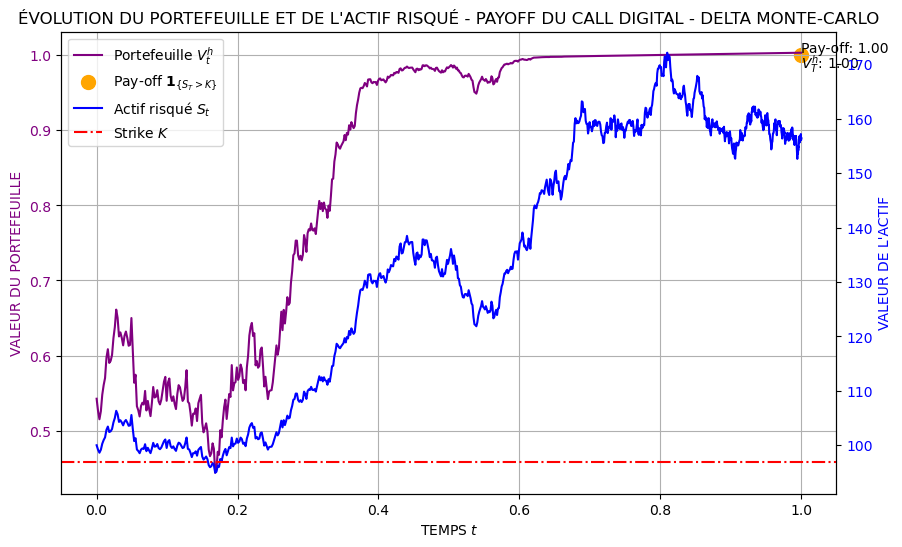

Valeur initiale du portefeuille : 0.5424488866885657
Valeur finale du portefeuille : 1.0034635549893682
Pay-off de l'option à maturité : 1.0
Erreur de réplication : 0.003463554989368234


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(4)

# paramètres du modèle de Black-Scholes / paramètres de l'option
S0 = 100 
sigma = 0.2
mu = 0.03
r = 0.015
b = 0.03  # Aligné avec le document (b = mu = 0.03)
K = 97
T = 1
liste_N = [10, 100, 500, 1000, 5000, 10000]
alpha = 2  # Paramètre pour la grille non uniforme
M_max = 100000  # Limite supérieure pour M_i


################# SIMULATION TRAJECTORIELLE DU PORTEFEUILLE ######################################
################# ESTIMATION DE L'ERREUR DE RÉPLICATION ##########################################
################# PAYOFF 1(S_T > K) ##############################################################
################# DELTA ESTIMÉ PAR MONTE CARLO ###################################################


# fonction pour estimer le delta par Monte-Carlo pour un call digital
def monte_carlo_delta_digital(t_i, S_t_i, T, r, sigma, K, h_i):
    M = int(T**2 / h_i**2)  # Nombre de trajectoires proportionnel à 1/h_i^2
    M = min(M, M_max)  # Limiter le nombre de trajectoires à proximité de l'échéance
    epsilon = 0.01 * S_t_i
    dt = T - t_i
    
    # Générer des lois normales pour les trajectoires
    Z = np.random.normal(0, 1, M)
    
    # Simuler S_T pour y = S_t_i + epsilon et S_t_i - epsilon
    S_T_plus = (S_t_i + epsilon) * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    S_T_minus = (S_t_i - epsilon) * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    # Calculer les payoffs (indicatrice pour call digital)
    payoff_plus = (S_T_plus > K).astype(float)  # 1 si S_T > K, 0 sinon
    payoff_minus = (S_T_minus > K).astype(float)
    
    # Estimateur du delta
    delta = np.exp(-r * dt) * np.mean(payoff_plus - payoff_minus) / (2 * epsilon)
    
    return delta

# simulation trajectorielle du portefeuille
def simulation_portefeuille_2_MC(N):
    # Grille temporelle non uniforme
    i = np.arange(N + 1)
    t = T * (1 - (1 - i / N)**alpha)  # Grille avec plus de points près de T
    h = np.diff(t)  # Pas de temps variables h_i
    S = np.zeros(N + 1)  # Trajectoire de l'actif risqué
    V = np.zeros(N + 1)  # Valeur du portefeuille
    deltas = np.zeros(N + 1)  # Quantités d'actif risqué

    # Initialisation
    S[0] = S0
    # Prix initial du call digital (exact)
    d2 = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    V[0] = np.exp(-r * T) * norm.cdf(d2)
    deltas[0] = monte_carlo_delta_digital(t[0], S[0], T, r, sigma, K, T / N)  # Utiliser h = T/N pour t_0

    # Simuler la trajectoire et mettre à jour le portefeuille
    for i in range(N):
        # Partie aléatoire de l'actif risqué
        h_i = h[i]  # Pas de temps variable
        N_i = np.random.normal(0, 1)
        
        # Évolution de Black-Scholes
        S[i + 1] = S[i] * np.exp(sigma * np.sqrt(h_i) * N_i + (b - 0.5 * sigma**2) * h_i)
        
        # Calcul du delta par Monte-Carlo
        if t[i] < T - 1e-6:
            deltas[i] = monte_carlo_delta_digital(t[i], S[i], T, r, sigma, K, h_i)
        else:
            deltas[i] = 0
        
        # Calcul de delta0_i (quantité d'actif sans risque détenue)
        S0_i = np.exp(r * t[i])
        delta0_i = (V[i] - deltas[i] * S[i]) / S0_i
        
        # Mise à jour de la valeur du portefeuille à t_{i+1}
        S0_ip1 = np.exp(r * t[i + 1])
        V[i + 1] = deltas[i] * S[i + 1] + delta0_i * S0_ip1
        
        # Delta pour le dernier pas
        if t[i + 1] < T - 1e-6:
            deltas[i + 1] = monte_carlo_delta_digital(t[i + 1], S[i + 1], T, r, sigma, K, h_i)
        else:
            deltas[i + 1] = 0

    payoff = (S[-1] > K).astype(float)  # Payoff du call digital
    erreur = V[-1] - payoff

    return t, S, V, payoff, erreur


# Visualisation
def trace_portefeuille_2_MC(N):
    t, S, V, payoff, erreur = simulation_portefeuille_2_MC(N)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Axe y principal pour le portefeuille V_t^h
    ax1.plot(t, V, label='Portefeuille $V_t^h$', color='purple')
    ax1.scatter([T], [payoff], label='Pay-off $\\mathbf{1}_{\\{S_T > K\\}}$', color='orange', marker='o', s=100)
    ax1.set_xlabel('TEMPS $t$')
    ax1.set_ylabel('VALEUR DU PORTEFEUILLE', color='purple')
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True)

    # Axe y secondaire pour l'actif risqué S_t
    ax2 = ax1.twinx()
    ax2.plot(t, S, label='Actif risqué $S_t$', color='blue')
    ax2.axhline(y=K, label='Strike $K$', color='red', linestyle='-.')
    ax2.set_ylabel('VALEUR DE L\'ACTIF', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    # Annotations
    ax1.text(T, payoff, f'Pay-off: {payoff:.2f}', verticalalignment='bottom')
    ax1.text(T, V[-1], f'$V_T^h$: {V[-1]:.2f}', verticalalignment='top')

    # Titre et légende
    plt.title('ÉVOLUTION DU PORTEFEUILLE ET DE L\'ACTIF RISQUÉ - PAYOFF DU CALL DIGITAL - DELTA MONTE-CARLO')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

    plt.show()
    
    # Afficher les résultats finaux
    print("Valeur initiale du portefeuille : " + str(V[0]))
    print("Valeur finale du portefeuille : " + str(V[-1]))
    print("Pay-off de l'option à maturité : " + str(payoff))
    print("Erreur de réplication : " + str(V[-1] - payoff))
    
trace_portefeuille_2_MC(1000)    
    

Cette fois-ci, on observe une erreur bien moindre ! La recalibration du portefeuille à plus haute fréquence près de la maturité permet d'observer numériquement la convergence du portefeuille vers le payoff.

On s'intéresse de nouveau à l'espérance empirique et la variance empirique d'un échantillon d'erreurs de réplication.

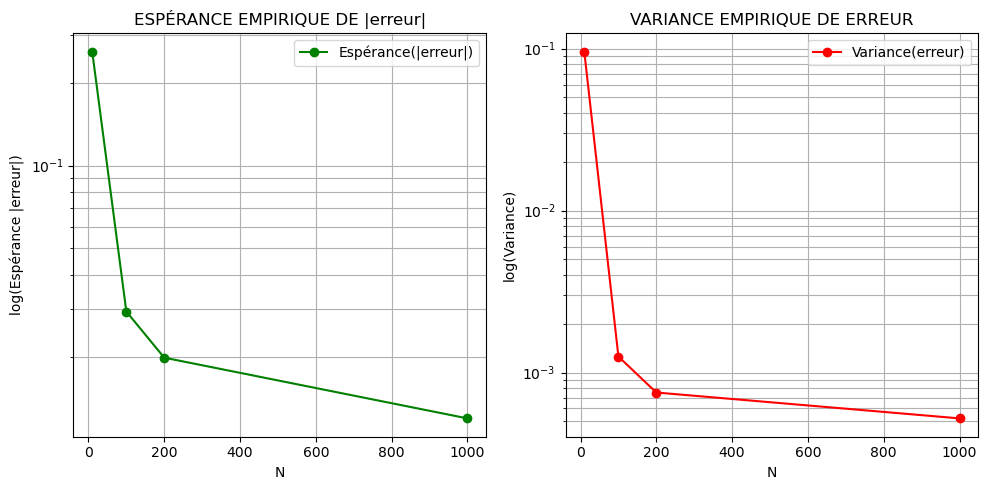

Valeurs de N : [10, 100, 200, 1000]
Espérance empirique de abs(erreur) :  [0.26049414317170905, 0.029376498785271894, 0.019945455110327324, 0.011978186199752288]
Variance empirique de erreur :  [0.09581387085553597, 0.0012550579062123952, 0.0007525639553870667, 0.0005209003160077889]


In [17]:
####################### ÉTUDE DE LA CONVERGENCE DE L'ERREUR DE RÉPLICATION #########################
####################### ÉTUDE DES MOMENTS DE L'ERREUR DE RÉPLICATION ###############################   

np.random.seed(4)
    
# on s'intéresse à la convergence de la stratégie en étudiant l'erreur de réplication
# Pour chaque valeur de N, on simule M variables aléatoires erreur(N) grâce à simulation
# On considère ensuite la variance empirique en l'espérance empirique de cette erreur(N)   
# On représente l'évolution de l'espérance de la valeur absolue et de la variance avec N
# On travaille en échelle semi-log pour montrer une décroissance en 1/N^alpha

def analyse_erreur_replication_2_MC(K, liste_N):
    
    variances = []
    esperances_abs = []

    for N in liste_N:
        erreurs = []

        for nb in range(K):
            para, para, para, para, erreur = simulation_portefeuille_2_MC(N)
            erreurs.append(erreur)

        # Calcul de la variance et de l'espérance de la valeur absolue
        variance = np.var(erreurs)
        esperance_abs = np.mean(np.abs(erreurs))

        variances.append(variance)
        esperances_abs.append(esperance_abs)

    # Tracé en semi-log : N linéaire, espérance et variance en log
    plt.figure(figsize=(10, 5))

    # Espérance de |erreur|
    plt.subplot(1, 2, 1)
    plt.semilogy(liste_N, esperances_abs, marker='o', color='green', label='Espérance(|erreur|)')
    plt.title("ESPÉRANCE EMPIRIQUE DE |erreur|")
    plt.xlabel("N")
    plt.ylabel("log(Espérance |erreur|)")
    plt.grid(True, which="both")
    plt.legend()

    # Variance de l'erreur
    plt.subplot(1, 2, 2)
    plt.semilogy(liste_N, variances, marker='o', color='red', label='Variance(erreur)')
    plt.title("VARIANCE EMPIRIQUE DE ERREUR")
    plt.xlabel("N")
    plt.ylabel("log(Variance)")
    plt.grid(True, which="both")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print("Valeurs de N :", liste_N)
    print("Espérance empirique de abs(erreur) : ", esperances_abs)
    print("Variance empirique de erreur : ", variances)
    
analyse_erreur_replication_2_MC(10, [10,100, 200, 1000])   

Ainsi, en adaptant la stratégie de réplication aux spécificités numériques du payoff grâce à une fréquence d'échantillonnage plus élevée à la maturité, on peut garantir la convergence du portefeuille.

## 3 - VERS LA CALIBRATION DES DONNÉES DE MARCHÉ



Montrons que $\hat{\sigma}_N^2$ est un estimateur fortement convergent de $\sigma^2$.

Rappelons que l'évolution de l'actif risqué est : $S_{t_i} = x \exp\left[\left(b - \frac{\sigma^2}{2}\right)t_i + \sigma \sqrt{h} \sum_{j=1}^i N_j\right]$, de sorte que $S_{t_{i+1}} = S_{t_i} \exp\left[\left(b - \frac{\sigma^2}{2}\right)h + \sigma \sqrt{h} N_{i+1}\right]$.

On en déduit que $\ln\left(\frac{S_{t_{i+1}}}{S_{t_i}}\right)^2 = \left[\left(b - \frac{\sigma^2}{2}\right)h + \sigma \sqrt{h} N_{i+1}\right]^2 = \lambda^2 h^2 + \sigma^2 h N_{i+1}^2 + 2 \sigma \lambda h^{3/2} N_{i+1}$ en notant pour alléger $\lambda := b - \frac{\sigma^2}{2}$.

En sommant cette expression, on réécrit notre estimateur sous la forme : 
$$\hat{\sigma}_N^2 = \frac{1}{T} \left[ N \lambda^2 h^2 + 2 \sigma \lambda h^{3/2} \sum_{i=0}^{N-1} N_{i+1} + \sigma^2 h \sum_{i=0}^{N-1} N_{i+1}^2 \right]$$

- Or $h^2 = \left( \frac{T}{N} \right)^2$ donc $Nh^2 \lambda^2 \xrightarrow[ N \to +\infty ]{\text{p.s.}} 0 $.

- Par ailleurs : $N_{i+1} \sim \mathcal{N}(0,1)$ et elles sont i.i.d. Donc les $N_{i+1}^2$ aussi par transfert d'indépendance, et elles sont d'espérance 1. Par la loi forte des grands nombres (LFGN), on en déduit $\frac{1}{N} \sum_{i=0}^{N-1} N_{i+1}^2 \xrightarrow[ N \to +\infty ]{\text{p.s.}} 1$, ou encore $\frac{1}{T} \sigma^2 h \sum_{i=0}^{N-1} N_{i+1}^2 \xrightarrow[ N \to +\infty ]{\text{p.s.}} \sigma^2$.

- Enfin, on note $T_N := h^{3/2} \sum_{i=0}^{N-1} N_{i+1}$ et $S_N := \sum_{i=0}^{N-1} N_{i+1}$ de sorte que $T_N = T^{3/2} \frac{S_N}{N^{3/2}}$. Les $N_{i+1}$ sont i.i.d et centrées donc par la loi forte des grands nombres (LFGN) $\frac{S_N}{N} \xrightarrow[ N \to +\infty ]{\text{p.s.}} 0$.

 Mais $\left| T_N \right| = \frac{T^{3/2}}{\sqrt{N}} \left| \frac{S_N}{N} \right| \leq T^{3/2} \left| \frac{S_N}{N} \right|$, et donc $\left| T_N \right| \xrightarrow[ N \to +\infty ]{\text{p.s.}} 0$.

 *Si on veut s'en convaincre, il suffit de considérer $X_n \xrightarrow[ N \to +\infty ]{\text{p.s.}} 0$ et $Y_n$ telles que $\left| Y_n \right| \leq X_n$. Considérons l'ensemble négligeable $N$ tel que $\forall \varpi \in N^c, X_n(\varpi) \xrightarrow[ N \to +\infty ]{\text{p.s.}} 0$. Alors on a également naturellement $\forall \varpi \in N^c, Y_n(\varpi) \leq \left| Y_n(\varpi) \right| \leq X_n(\varpi) \xrightarrow[ N \to +\infty ]{\text{p.s.}} 0$.*

Finalement, en regroupant ces trois termes (et par continuité de la somme), on a bien $$\boxed{\hat{\sigma}_N^2 \xrightarrow[ N \to +\infty ]{\text{p.s.}} \sigma^2}$$

Désormais on cherche un estimateur du paramètre de tendance b.

- Supposons que l'on observe simultanément la trajectoire d'un grand nombre d'actifs qui ont tous la même dynamique (on les note $(S_{t_i}^n)_n$), en particulier le même paramètre de tendance $b$. Rappelons qu'on a montré $\mathbb{E}(S_{t_i}^n) = S_0^n \exp(bt_i)$. Si l'on note $X_n := \frac{S_T^n}{S_0^n}$, on a $\mathbb{E}(X_n) = \exp(bT)$.
Comme $x \longmapsto \exp(Tx)$ est bicontinue, par la méthode des moments, on obtient un estimateur fortement convergent de $b$ : $$\boxed{\tilde{b}_n := \frac{1}{T} \ln \left[ \frac{1}{n} \sum_{j=0}^{n} \frac{S_T^j}{S_0^j} \right] \xrightarrow[ n \to +\infty ]{\text{p.s.}} b}$$ Toutefois, cela suppose que l'on observe un grand nombre de trajectoires simultanément !

- Cependant, cela ne semble pas être l'idée suggérée par notre approche jusqu'ici : on s'est plutôt intéressés à la trajectoire d'un seul actif, et il faudrait plutôt construire un estimateur qui exploite le pas de discrétisation. Autrement dit, un estimateur qui n'utilise que l'évolution de l'actif entre les instants $t_i$ successifs et qui soit convergent avec $N$. Notons $X_i := \ln \left[ \frac{S_{t_{i+1}}}{S_{t_i}} \right]$ pour $i \in [0, N-1]$. Comme montré précédemment, $X_i = \left(b - \frac{\sigma^2}{2}\right)h + \sigma \sqrt{h} N_{i+1}$. Donc $\mathbb{E}(X_i) = \left( b - \frac{\sigma^2}{2} \right)h$.

 Par la loi forte des grands nombres (LFGN), $\Gamma_N := \frac{1}{Nh} \sum_{i=0}^{N-1} X_i \xrightarrow[ N \to +\infty ]{\text{p.s.}} b - \frac{\sigma^2}{2}$.

 Ainsi, on dispose de :
$$\left\{
\begin{array}{ll}
\Gamma_N \xrightarrow[ N \to +\infty ]{\text{p.s.}} b - \frac{\sigma^2}{2} \\
\hat{\sigma}_N^2 \xrightarrow[ N \to +\infty ]{\text{p.s.}} \sigma^2
\end{array}
\right.$$

 et donc on a bien $\Gamma_N + \frac{\hat{\sigma}_N^2}{2} \xrightarrow[ N \to +\infty ]{\text{p.s.}} b$ par continuité.

 En conclusion, un estimateur fortement convergent de $b$ est : 
$$\boxed{\hat{b}_N := \frac{1}{T} \sum_{i=0}^{N-1} \left[ \ln \left(\frac{S_{t_{i+1}}}{S_{t_i}}\right) + \frac{1}{2} \ln \left(\frac{S_{t_{i+1}}}{S_{t_i}}\right)^2 \right] \xrightarrow[ N \to +\infty ]{\text{p.s.}} b}$$



 

On s'intéresse à l'application des résultats obtenus tout au long de ce problème avec des données réelles de marché. L'objectif est de vérifier la cohérence et la pertinence du modèle proposé

Récupérons tout d'abord les données de clôtures journalières d'un actif à étudier. Notons que dans le modèle étudié, l'actif ne doit pas générer de dividendes non pris en compte dans sa valeur, ce qui ne rendrait plus compte de sa valeur dans le cadre de notre modèle de travail. Ainsi, on préférera étudier un indice de performance, comme le DAX (qui est calculé avec dividendes réinvestis), à un indice composite, comme le CAC40 (une version pertinente serait le CAC40 Gross Return, qui réintègre les dividendes). On prend un horizon de temps de 1 an pour simuler la stratégie de couverture. 

Cette méthode impose d'installer la librairie $\text{yfinance}$ via la cellule suivante, mais a l'avantage qu'on peut ensuite changer d'actif dans le code grâce à la connaissance de son ticker.

On suppose qu’on a affaire à une réalisation de Black-Scholes pour cet actif. La formule $(5.6)$ nous donne alors une estimation de la volatilité associée. On prendra garde au paramètrage du problème, l'horizon de temps d'un an choisi devant en réalité correspondre au nombre de jours de cotation en Bourse sur la période, qui varie autour de 250 jours par an en moyenne. 

On récupère ainsi dans un premier temps une estimation la volatilité via le script suivant : 


In [1]:
!pip install yfinance

In [2]:

### méthode 1 : via librairie yfinance

import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# Paramètres : ticker DAX et période de 1 an au moment où ce code a été mis à jour ; on modifie aisément le paramètrage ; 
# Pour tester d'autres actifs, il suffit de modifier le paramètre ticker qui suit : par exemple, pour le Bitcoin, indiquer 'BTC-USD' .

ticker = '^GDAXI'
debut = '2024-07-04'
fin = '2025-07-04'


# 1. Téléchargement des données via yfinance ; si un Dataframe pourrait convenir pour stocker les données via la librairie panda, on se limite simplement ici aux librairies recommandées

data = yf.Ticker(ticker).history(start=debut, end=fin, interval='1d')

# 2. Extraction des prix de clôture
closes1 = data['Close'].values

# On fournit le code suivant permettant d'afficher le cours de l'actif en entrée sur un an ; pour afficher, enlever les guillemets.
"""
# Représentation graphique des prix de clôture
plt.figure(figsize=(10,5))
plt.plot(closes1, label='DAX (Clôture)')
plt.title('Évolution du DAX (Prix de clôture)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture (points)')
plt.grid(True)
plt.legend()
plt.show()
"""

# 3. Calcul des rendements log
rendementlogarithme = np.log(closes1[1:] / closes1[:-1])

# 4. Nombre effectif de jours de cotation sur la période
N_cota = len(rendementlogarithme)
print(f"Nombre de jours de cotation observés : {N_cota}")


# Estimation de la volatilité annualisée avec N_cota jours de cotation par an
volatilite1 = np.sqrt(252 * np.mean(rendementlogarithme**2))

# Affichage
print(f"Volatilité estimée sur 1 an : {volatilite1:.4f} soit {volatilite1*100:.2f}%")

Nombre de jours de cotation observés : 252
Volatilité estimée sur 1 an : 0.1796 soit 17.96%


Intéressons nous maintenant au prix d'une option associée dans le modèle de Black Scholes, pour laquelle on met en place notre stratégie de couverture.

On suppose que l’on dispose sur le marché considéré d'un actif sans risque à taux d’intérêt constant $r \geq 0$ dont la dynamique est régie par l’équation différentielle $(5.2)$. Des exemples de placement raisonnablement sans risques courants sont le livret A, au rendement annuel de 3% (mais qui n'est évidemment pas utilisable ici du fait du plafond associé), les bons du trésor à taux fixes, et les obligations d'Etat, comme les OAT. Dans le cadre du problème, pour l'horizon de temps choisi, nous choisirons comme placement judicieux les BTF 12 mois, avec un taux de rendement que nous fixerons à $r = 3 $% en nous basant sur les émissions moyennes de l'ATF émises au début de la plage temporelle (on peut vérifier cette modélisation en s'intéressant à l'historique des adjudications via : https://www.aft.gouv.fr/fr/dernieres-adjudications).

Enfin, le strike K choisi dans le paramètrage du problème dépend de l'objectif donné au portefeuille. En l'occurence, les calls "out-of-the-money" ($K > S_0$) sont pertinents, si l'acheteur souhaite jouer sur l'effet de levier plus fort, mais aussi les calls "in the money/at the money". On propose dans le modèle qui suit un strike in-the-money 10% au-dessus de $S_0$, sur lequel on peut jouer dans le script suivant pour simuler différentes options. 

Prix initial de l'option selon Black-Scholes (on rappelle que cela correspond également à la valeur initiale du portefeuille) : 2738.3996
Valeur finale du portefeuille: 7406.3069
Payoff à maturité: 7328.6984
Écart final portefeuille - payoff: 77.6084


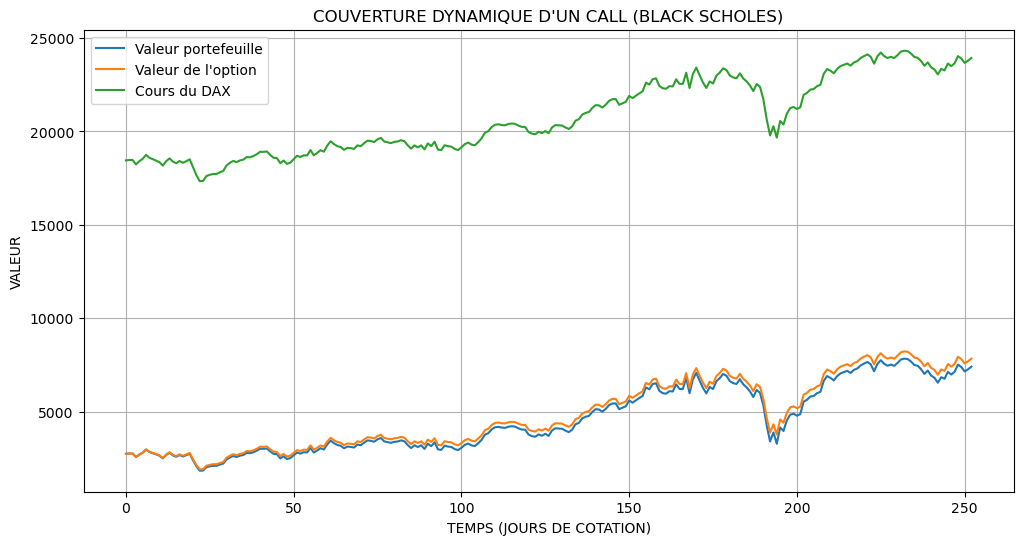

In [19]:
#### ATTENTION : ici, on utilise les données de closes1 extraites grâce au premier programme ; bien modifier le programme si on récupère les données via la seconde méthode.


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Les données sont déjà stockées en mémoire en ayant lancé les programmes qui précèdent.

# Paramètres
r = 0.03  # taux sans risque annuel, ici via BTF - à réajuster en focntion de la plage temporel choisi
T = 1.0   # maturité en années
sigma = volatilite1  # volatilité annualisée estimée - ATTENTION : prendre garde à l'indice de la volatilité, volatilite1 correspondant à l'estimation renvoyée par la première méthode, et volatilite2 à l'estimation par la deuxième méthode
K = closes1[0]*0.9 # strike choisi in the money, à modifier suivant les options que l'ont souhaite simuler
N = len(closes1) - 1  # nombre d'incréments
dt = T / N          # pas de temps

# Fonction Black-Scholes pour call
def prix_call(S, K, T, r, sigma):
    if T == 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    
# Fonction Black-Scholes pour put - cette fonction est masquée, mais peut être utilisé si l'on veut simuler le même procédé pour un put cette fois / faire une simulation grâce à la formule de parité
"""
def prix_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma* np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
"""

# Fonction delta call - on reprend la formule obtenu en **S2**.
def delta_call(S, K, T, r, sigma):
    if T == 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Initialisation
valeur_portefeuille = []
actif_sans_risque = []
option = []
ecart = [] #on implémente également une liste contenant l'écart entre la valeur du portefeuille et la valeur de l'option
part = 0

#  portefeuille initial : achat de delta_0 actions, le reste en cash, de sorte que la valeur initiale du portefeuille soit celle de l'option

option.append(prix_call(closes1[0], K, T, r, sigma))
part = delta_call(closes1[0], K, T, r, sigma)
actif_sans_risque.append(option[0] - part * closes1[0])
valeur_portefeuille.append(option[0])
ecart.append(0)

# Simulation de la couverture dynamique par discrétisation
for i in range(1, N + 1):
    t = i * dt
    temps_rest = T - t
    
    # Nouvelle valeur de l'option
    nouvcall = prix_call(closes1[i], K, T, r, sigma)
    option.append(nouvcall)
    
    # Nouveau delta
    nouvdelta = delta_call(closes1[i], K, temps_rest, r, sigma)
    
    # Ajustement du portefeuille
    delta_change = nouvdelta - part
    actif_sans_risque.append(actif_sans_risque[i-1] * np.exp(r * dt) - delta_change * closes1[i])
    part = nouvdelta
    
    valeur = part * closes1[i] + actif_sans_risque[i]
    valeur_portefeuille.append(valeur)
    
    # Nouvelle écart
    ecart.append(valeur_portefeuille[i] - max(closes1[i] - K, 0))



# Affichage des résultats à maturité
print(f"Prix initial de l'option selon Black-Scholes (on rappelle que cela correspond également à la valeur initiale du portefeuille) : {prix_call(closes1[0], K, T, r, sigma):.4f}")
print(f"Valeur finale du portefeuille: {valeur_portefeuille[-1]:.4f}")
print(f"Payoff à maturité: {valeur_portefeuille[-1] - ecart[-1] :.4f}")
print(f"Écart final portefeuille - payoff: {ecart[-1]:.4f}")

# Graphique de la valeur du portefeuille vs valeur de l'option
plt.figure(figsize=(12,6))
plt.plot(valeur_portefeuille, label='Valeur portefeuille')
plt.plot(option, label="Valeur de l'option")
# ATTENTION : pour des options très risquées (au strike élevé pour le call étudié ici), l'écart entre la valeur de l'option et le cours de l'actif peut rendre illisible la lecture dugraphique : il est alors préférable de mettre ceci entre guillemets
plt.plot(closes1, label='Cours du DAX')
plt.title("COUVERTURE DYNAMIQUE D'UN CALL (BLACK SCHOLES)")
plt.xlabel("TEMPS (JOURS DE COTATION)")
plt.ylabel("VALEUR")
plt.legend()
plt.grid()
plt.show()

Ainsi, la stratégie de couverture proposée semble offrir une modélisation fidèle de l'option associée à l'actif choisi, puisque s'appliquant convenablement pour les données de marché fournies. On retrouve également bien, comme attendu précédemment, que $\Delta_T^h$ est petit devant devant le prix de l'option, ce qui est cohérent puisque la plage de temps choisie est grande, assurant une discrétisation suffisante et une convergence de l'erreur dans le cadre de notre stratégie delta. Enfin, cette modélisation conforte l'hypothèse de la pertinence du modèle de Black Scholes pour évaluer l'évolution du prix d'un actif. Cette hypothèse de dynamique semble donc cohérente pour certains actifs précis : les indices boursiers majeurs, comme le DAX, car ils prennent en compte suffisamment de valeurs pour permettre de limiter les sauts brutaux (qui, à en suivre la figure, induisent souvent le plus grand écart entre la valeur del'option et du portefeuille) ; les grandes capitalisations boursières liquides à court terme semblent également pertinentes, car généralement peu sujettes à des variation subites. A l'opposé, la dynamique de certains actifs ne seraient pas modélisée correctement par le modèle de Black-Scholes, comme nous le verrons dans les limites du modèle en partie suivante.

## **CONCLUSION**

Si les options peuvent être vues comme des contrats contingents, consistant en un contrat de transfert de risque moyennant un prix, tout l'enjeu pour l'émetteur est dès lors de s'assurer d'être en mesure de rembourser l'acheteur à maturité. Ainsi, il peut procéder à la couverture des options via la structuration d'un portefeuille. Dans le modèle de Black-Scholes, nous avons vu qu'une telle structuration, fondée sur un juste équilibre (en l'occurrence, calibré via le *delta*) entre le sous-jacent du call et un actif sans risque au rendement connu d'avance, permet d'ajuster dynamiquement la position en actif sous-jacent pour neutraliser le risque du marché. 

Partant des premières relations obtenues dans la modélisation du problème en partie 1, nous avons établi des méthodes numériques pertinentes permettant de modéliser le problème : simulation de l'évolution du prix de l'actif et de la stratégie delta directement et en passant par des estimateurs, estimation de la volatilité, ... La pertinence des simulations numériques repose en particulier sur la convergence des modèles discrets employés vers les résultats obtenus dans le cas continu, comme établi plus haut et L'application du modèle offre enfin un bon calibrage lors de l'utilisation de données de marché, confortant l'intérêt du modèle de Black-Scholes et l'optique pour l'émetteur de sécuriser les risques associés au contrat.

Pour autant, le modèle présente divers limites liées à la nature même de la modélisation et au paramétrage. Il ne prend ainsi pas en compte les dividendes, excluant bon nombre d'actifs disponibles sur les marchés des options. Une réadaptation des formules pour intégrer les dividendes est tout à fait envisageable : on peut considérer qu'une proportion $\delta$ est payée à chaque intervalle de temps, et ainsi la modélisation de la valeur de l'actif devient à $i$ donné : $$ S_{t_i} = x (1 - \sigma) ^i\exp\left(\left(b - \frac{\sigma^2}{2} \right)t_i + \sigma \sqrt{h} \sum_{j=1}^{i}N_j \right) $$ On peut reprendre les calculs et obtenir des expressions réadaptées pour la relation de parité et les valeurs des calls et puts. Par ailleurs, on exclut également ici les options américaines, qui permettent l'exercice à toute date avant maturité. On suppose également que les volumes de transaction sont toujours légitimes et sans influence sur la valeur de l'actif, et qu'il n'y a pas de frais de transaction. Enfin, le modèle reste dépend d'un rebalancement régulier, le rendant vulnérable sur des journées de fortes évolutions sur les marchés financiers, un rebalancement continu étant bien sûr irréaliste.

Un point important est celui du choix de nos méthodes numériques de couverture : dans le cas d'un call standard, un couverture delta classique suffisait. Pour un call digital (dont le payoff est binaire selon la valeur du sous-jacent par rapport au strike), cette stratégie ne faisait plus converger l'erreur de portefeuille. Il a fallu adapter notre méthode de Monte-Carlo en trouvant un équilibre entre trajectoires simulées et fréquence de calibrage.